In [249]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import platform

# 운영체제별 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumGothic')

# 마이너스 부호 깨짐 해결
plt.rcParams['axes.unicode_minus'] = False    

In [250]:
df = pd.read_csv('data/real_estate_clean_v1.csv', encoding='cp949')

print(len(df))

# 동자동 트윈시티 남산 매물을 이상치로 판단하고 제거
target = df[(df['BLDG_NM']=='트윈시티 남산') & (df['ARCH_AREA']==488.54)]

df = df.drop(target.index)

# 입주권 제거
df = df[df['RGHT_SE'] != '입주권'].copy()

print(len(df))

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_79136/41715357.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_clean_v1.csv', encoding='cp949')


794606
789955


In [251]:
df['bungi'] = df['CTRT_DAY'].astype(str).str[5:7]
df['bungi_int'] = df['bungi'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 789955 entries, 0 to 794605
Data columns (total 18 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  789955 non-null  int64  
 1   CGG_CD      789955 non-null  int64  
 2   CGG_NM      789955 non-null  object 
 3   STDG_CD     789955 non-null  int64  
 4   STDG_NM     789955 non-null  object 
 5   BLDG_NM     736793 non-null  object 
 6   CTRT_DAY    789955 non-null  object 
 7   THING_AMT   789955 non-null  int64  
 8   ARCH_AREA   789955 non-null  float64
 9   LAND_AREA   629015 non-null  float64
 10  FLR         736844 non-null  float64
 11  RGHT_SE     2389 non-null    object 
 12  ARCH_YR     789955 non-null  int64  
 13  BLDG_USG    789955 non-null  object 
 14  DCLR_SE     212915 non-null  object 
 15  CTRT_YEAR   789955 non-null  int64  
 16  bungi       789955 non-null  object 
 17  bungi_int   789955 non-null  int64  
dtypes: float64(3), int64(7), object(8)
memory usage: 

In [252]:
# 1. 함수 정의 (매개변수 x는 행의 특정 값)
def get_bungi(x):
    if x < 4:
        return 'Q1'
    elif x < 7:
        return 'Q2'
    elif x < 10:
        return 'Q3'
    else:
        return 'Q4'

# 2. apply 함수를 이용해 bungi_int 컬럼의 모든 값에 적용
df['bungi'] = df['CTRT_YEAR'].astype(str) + df['bungi_int'].apply(get_bungi)

df['bungi']

0         2019Q2
1         2019Q1
2         2019Q1
3         2019Q1
4         2019Q1
           ...  
794601    2023Q4
794602    2023Q4
794603    2023Q4
794604    2023Q4
794605    2023Q4
Name: bungi, Length: 789955, dtype: object

In [253]:
# 2024Q4 데이터 제거
remove = df[df['bungi']=='2024Q4']
df = df.drop(remove.index)

# 잘 제거 되었는지 확인
df['bungi'].value_counts().sort_index(ascending=False)

bungi
2024Q3    27308
2024Q2    26359
2024Q1    17811
2023Q4    14229
2023Q3    19434
2023Q2    18922
2023Q1    13899
2022Q4     8809
2022Q3    12130
2022Q2    22515
2022Q1    16965
2021Q4    22317
2021Q3    31859
2021Q2    37432
2021Q1    36718
2020Q4    39455
2020Q3    42004
2020Q2    46573
2020Q1    38056
2019Q4    55195
2019Q3    38335
2019Q2    29180
2019Q1    17094
2018Q4    20805
2018Q3    50140
2018Q2    31926
2018Q1    53613
Name: count, dtype: int64

In [254]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 789083 entries, 0 to 794605
Data columns (total 18 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  789083 non-null  int64  
 1   CGG_CD      789083 non-null  int64  
 2   CGG_NM      789083 non-null  object 
 3   STDG_CD     789083 non-null  int64  
 4   STDG_NM     789083 non-null  object 
 5   BLDG_NM     735942 non-null  object 
 6   CTRT_DAY    789083 non-null  object 
 7   THING_AMT   789083 non-null  int64  
 8   ARCH_AREA   789083 non-null  float64
 9   LAND_AREA   628143 non-null  float64
 10  FLR         735993 non-null  float64
 11  RGHT_SE     2382 non-null    object 
 12  ARCH_YR     789083 non-null  int64  
 13  BLDG_USG    789083 non-null  object 
 14  DCLR_SE     212043 non-null  object 
 15  CTRT_YEAR   789083 non-null  int64  
 16  bungi       789083 non-null  object 
 17  bungi_int   789083 non-null  int64  
dtypes: float64(3), int64(7), object(8)
memory usage: 

In [255]:
print(f"제거 전 행 개수: {len(df)}")

제거 전 행 개수: 789083


In [256]:
# 건물용도별 데이터프레임 분리
df1 = df[df['BLDG_USG']=='단독다가구']
df2 = df[df['BLDG_USG']=='아파트']
df3 = df[df['BLDG_USG']=='연립다세대']
df4 = df[df['BLDG_USG']=='오피스텔']

In [257]:
# 1. 처리할 데이터프레임과 이름을 리스트로 관리
dfs = [df1, df2, df3, df4]
cleaned_dfs = []

for target_df in dfs:
    # 2. 상위 1.5% (0.985 분위수) 임계값 계산
    threshold = target_df['THING_AMT'].quantile(0.985)
    
    # 3. 임계값 이하의 데이터만 추출 (상위 1.5% 제거)
    under_985 = target_df[target_df['THING_AMT'] <= threshold].copy()
    cleaned_dfs.append(under_985)

# 4. 하나의 데이터프레임으로 다시 통합
df = pd.concat(cleaned_dfs).reset_index(drop=True)

print(f"제거 후 행 개수: {len(df)}")

제거 후 행 개수: 777307


In [258]:
789083*0.985

777246.755

In [259]:
# 평당가 구하기
# 전용면적(평수): 부동산에서 순수하게 거주할 수 있는 면적
# df 데이터에서 나타내는 건물면적: 전용면적
# 1평은 약 **3.3058$m^2$**에 해당
# 평당가 = 건물가격 / 건물면적 * 3.3058
df['unit_price'] = df['THING_AMT'] / df['ARCH_AREA'] * (3.3058)

In [260]:
df = pd.read_csv('data/real_estate_clean_v2.csv', encoding='cp949')
df

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_79136/1714618046.py:1: DtypeWarning: Columns (12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_clean_v2.csv', encoding='cp949')


,Unnamed: 0.1,Unnamed: 0,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,...,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,QUARTER,QUARTER_INT,CTRT_BLDG_AGE,AMT_PER_AREA,AMT_PER_PYEONG
0,0,14,11530,구로구,10800,오류동,NaN,2018-12-31,73000,197.40,...,NaN,1990,단독다가구,NaN,2018,2018Q4,12,28,369.807497,1222.509625
1,1,16,11215,광진구,10100,중곡동,NaN,2018-12-31,102000,89.09,...,NaN,1973,단독다가구,NaN,2018,2018Q4,12,45,1144.909642,3784.842294
2,2,43,11560,영등포구,10900,영등포동8가,NaN,2018-12-29,88700,36.36,...,NaN,1945,단독다가구,NaN,2018,2018Q4,12,73,2439.493949,8064.479098
3,3,87,11230,동대문구,10900,휘경동,NaN,2018-12-28,95000,140.22,...,NaN,1991,단독다가구,NaN,2018,2018Q4,12,27,677.506775,2239.701897
4,4,92,11620,관악구,10200,신림동,NaN,2018-12-27,56500,179.46,...,NaN,1988,단독다가구,NaN,2018,2018Q4,12,30,314.833389,1040.776218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777302,777302,833566,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,...,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777303,777303,833567,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,...,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777304,777304,833568,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,...,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777305,777305,833569,11650,서초구,10800,서초동,벨라채 오피스텔,2023-12-04,24000,36.64,...,NaN,2003,오피스텔,중개거래,2023,2023Q4,12,20,655.021834,2165.371179


In [261]:
# 건물용도별 분기별 평균 거래금액 데이터
mean_amt_bungi = df.groupby(['BLDG_USG','bungi'], as_index=False)['THING_AMT'].mean() 
mean_amt_bungi

KeyError: 'bungi'

In [ ]:
# 건물용도별로 나누어 분기별 건물가격 확인
dan = mean_amt_bungi[mean_amt_bungi['BLDG_USG']=='단독다가구'].copy()
apt = mean_amt_bungi[mean_amt_bungi['BLDG_USG']=='아파트'].copy()
yeon = mean_amt_bungi[mean_amt_bungi['BLDG_USG']=='연립다세대'].copy()
off = mean_amt_bungi[mean_amt_bungi['BLDG_USG']=='오피스텔'].copy()

In [ ]:
# 건물용도별 분기별 평균 평당가 데이터
mean_unit_price_bungi = df.groupby(['BLDG_USG','bungi'], as_index=False)['unit_price'].mean() 
mean_unit_price_bungi

,BLDG_USG,bungi,unit_price
0,단독다가구,2018Q1,2088.761646
1,단독다가구,2018Q2,2108.204030
2,단독다가구,2018Q3,2236.906668
3,단독다가구,2018Q4,2258.703560
4,단독다가구,2019Q1,2346.294961
...,...,...,...
103,오피스텔,2023Q3,2673.670423
104,오피스텔,2023Q4,2785.598919
105,오피스텔,2024Q1,2931.286327
106,오피스텔,2024Q2,2717.180358


In [ ]:
# 건물용도별로 나누어 분기별 건물가격 확인
dan2 = mean_unit_price_bungi[mean_unit_price_bungi['BLDG_USG']=='단독다가구'].copy()
apt2 = mean_unit_price_bungi[mean_unit_price_bungi['BLDG_USG']=='아파트'].copy()
yeon2 = mean_unit_price_bungi[mean_unit_price_bungi['BLDG_USG']=='연립다세대'].copy()
off2 = mean_unit_price_bungi[mean_unit_price_bungi['BLDG_USG']=='오피스텔'].copy()

In [ ]:
# 건물용도별 분기별 건물가격의 증감폭
dan['diff'] = dan['THING_AMT'].diff().fillna(0)
apt['diff'] = apt['THING_AMT'].diff().fillna(0)
yeon['diff'] = yeon['THING_AMT'].diff().fillna(0)
off['diff'] = off['THING_AMT'].diff().fillna(0)

In [ ]:
# 건물용도별 분기별 평당가의 증감폭
dan2['diff'] = dan2['unit_price'].diff().fillna(0)
apt2['diff'] = apt2['unit_price'].diff().fillna(0)
yeon2['diff'] = yeon2['unit_price'].diff().fillna(0)
off2['diff'] = off2['unit_price'].diff().fillna(0)

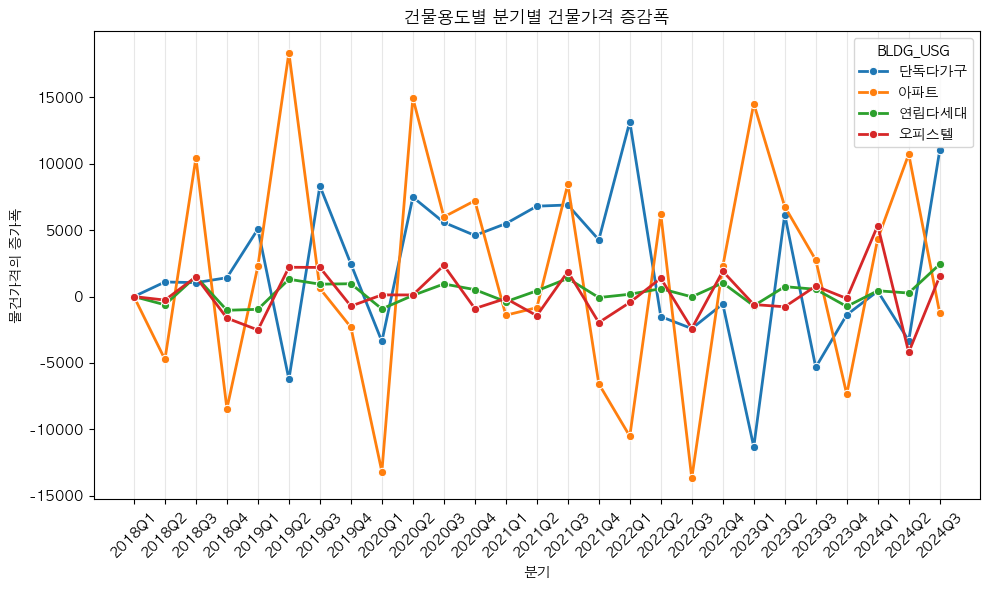

In [ ]:
# 건물용도 통합본 생성
df_all = pd.concat([dan, apt, yeon, off])

# 건물용도별 분기별 건물 가격의 증감폭
plt.figure(figsize=(10,6))
sns.lineplot(data=df_all, x='bungi', y='diff', hue='BLDG_USG',
             marker='o', linewidth=2)
plt.title("건물용도별 분기별 건물가격 증감폭")
plt.xlabel("분기")
plt.ylabel("물건가격의 증가폭")
plt.xticks(rotation=45)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

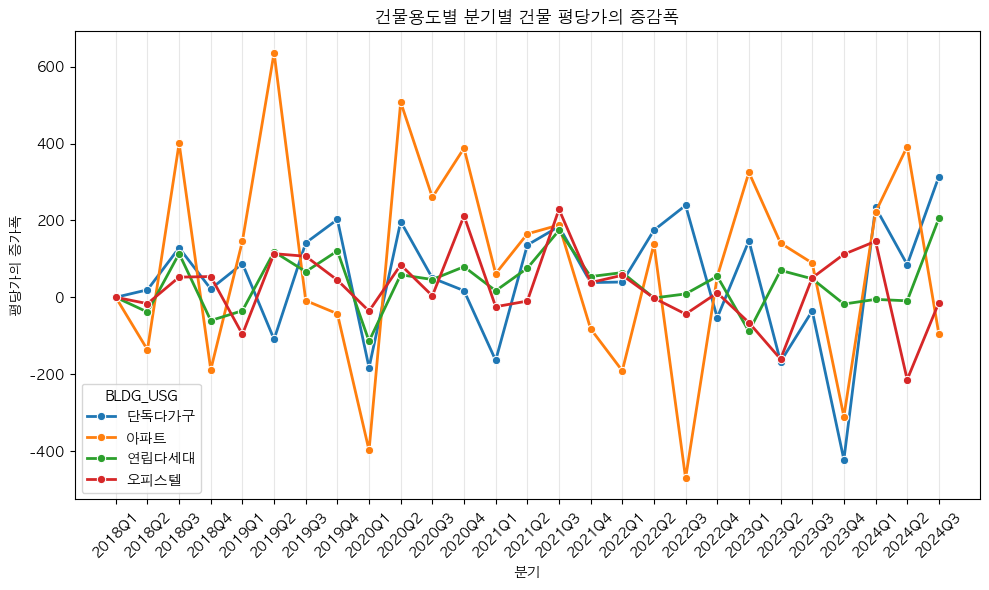

In [ ]:
# 건물용도 통합본 생성
df_all2 = pd.concat([dan2, apt2, yeon2, off2])

# 건물용도별 분기별 건물 평당가의 증감폭
plt.figure(figsize=(10,6))
sns.lineplot(data=df_all2, x='bungi', y='diff', hue='BLDG_USG',
             marker='o', linewidth=2)
plt.title("건물용도별 분기별 건물 평당가의 증감폭")
plt.xlabel("분기")
plt.ylabel("평당가의 증가폭")
plt.xticks(rotation=45)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

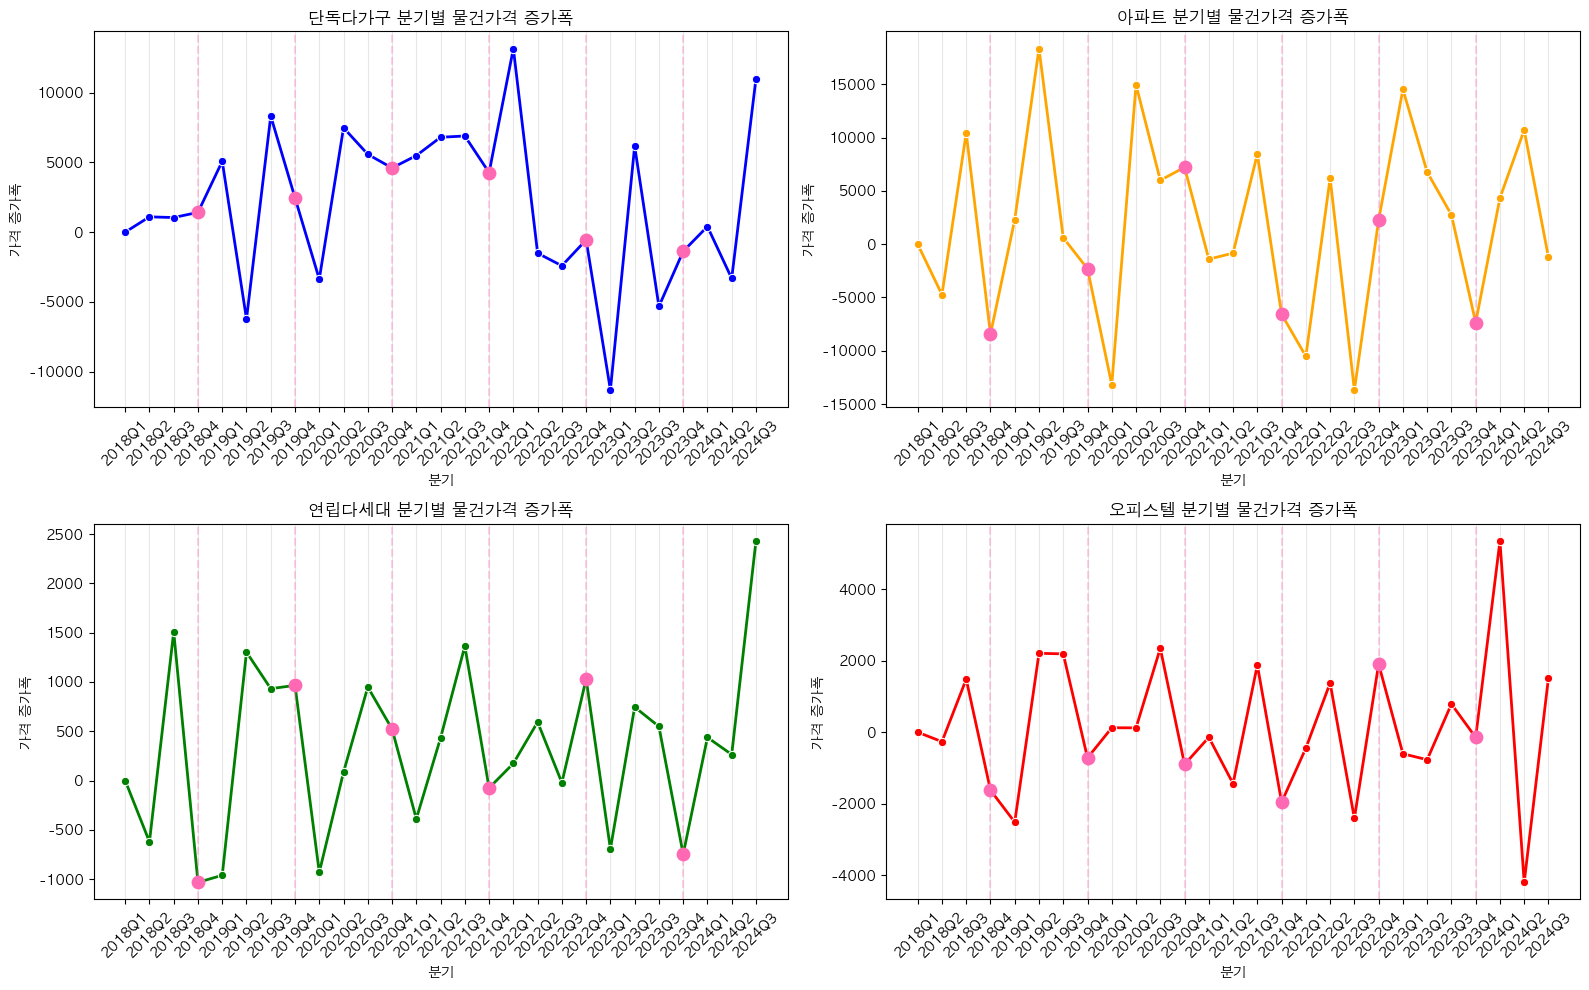

In [ ]:
# 건물용도별 분기별 물건가격 증가폭 그래프 비교

import matplotlib.pyplot as plt
import seaborn as sns

# 1. 설정 및 데이터 준비
plt.rcParams['axes.unicode_minus'] = False 
target_dataframes = [dan, apt, yeon, off]
titles = ['단독다가구', '아파트', '연립다세대', '오피스텔']
colors = ['Blues', 'Oranges', 'Greens', 'Reds']

# 2. 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten() # 2차원 배열을 1차원으로 펼쳐 반복문을 쉽게 만듦

for i, dataframe in enumerate(target_dataframes):
    ax = axes[i]
    
    # 그래프 그리기 (palette 대신 단일 색상 사용 시 color 인자 활용)
    sns.lineplot(data=dataframe, x='bungi', y='diff', marker='o', 
                 linewidth=2, ax=ax, color=colors[i][:-1].lower()) # 예: 'Blues' -> 'blue'
    
    # 4주기(연말) 강조 로직
    for j, label in enumerate(dataframe['bungi']):
        if label.endswith('Q4'):
            ax.axvline(x=j, color='hotpink', linestyle='--', alpha=0.3)
            ax.scatter(j, dataframe['diff'].iloc[j], color='hotpink', s=80, zorder=5)
    
    # 개별 그래프 설정
    ax.set_title(f"{titles[i]} 분기별 물건가격 증가폭", fontsize=12)
    ax.set_xlabel("분기")
    ax.set_ylabel("가격 증가폭")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='x', alpha=0.3)

# 전체 레이아웃 조정
plt.tight_layout()
plt.show()

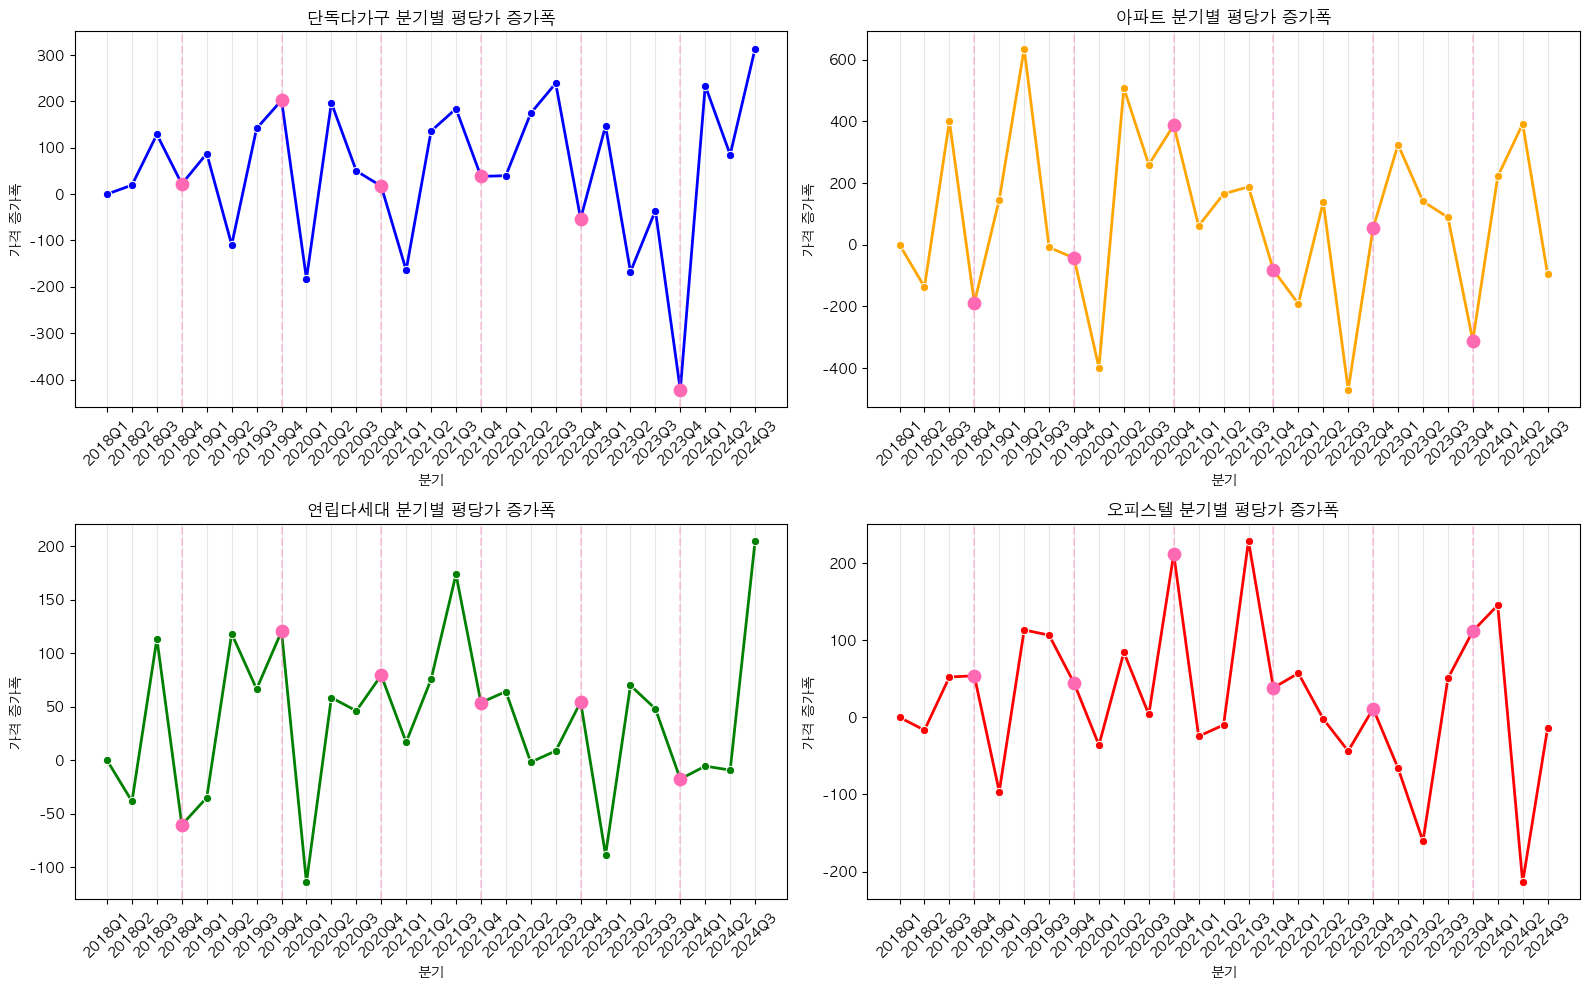

In [ ]:
# 건물용도별 분기별 평당가의 증가폭 그래프 비교

import matplotlib.pyplot as plt
import seaborn as sns

# 1. 설정 및 데이터 준비
plt.rcParams['axes.unicode_minus'] = False 
target_dataframes = [dan2, apt2, yeon2, off2]
titles = ['단독다가구', '아파트', '연립다세대', '오피스텔']
colors = ['Blues', 'Oranges', 'Greens', 'Reds']

# 2. 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten() # 2차원 배열을 1차원으로 펼쳐 반복문을 쉽게 만듦

for i, dataframe in enumerate(target_dataframes):
    ax = axes[i]
    
    # 그래프 그리기 (palette 대신 단일 색상 사용 시 color 인자 활용)
    sns.lineplot(data=dataframe, x='bungi', y='diff', marker='o', 
                 linewidth=2, ax=ax, color=colors[i][:-1].lower()) # 예: 'Blues' -> 'blue'
    
    # 4주기(연말) 강조 로직
    for j, label in enumerate(dataframe['bungi']):
        if label.endswith('Q4'):
            ax.axvline(x=j, color='hotpink', linestyle='--', alpha=0.3)
            ax.scatter(j, dataframe['diff'].iloc[j], color='hotpink', s=80, zorder=5)
    
    # 개별 그래프 설정
    ax.set_title(f"{titles[i]} 분기별 평당가 증가폭", fontsize=12)
    ax.set_xlabel("분기")
    ax.set_ylabel("가격 증가폭")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='x', alpha=0.3)

# 전체 레이아웃 조정
plt.tight_layout()
plt.show()

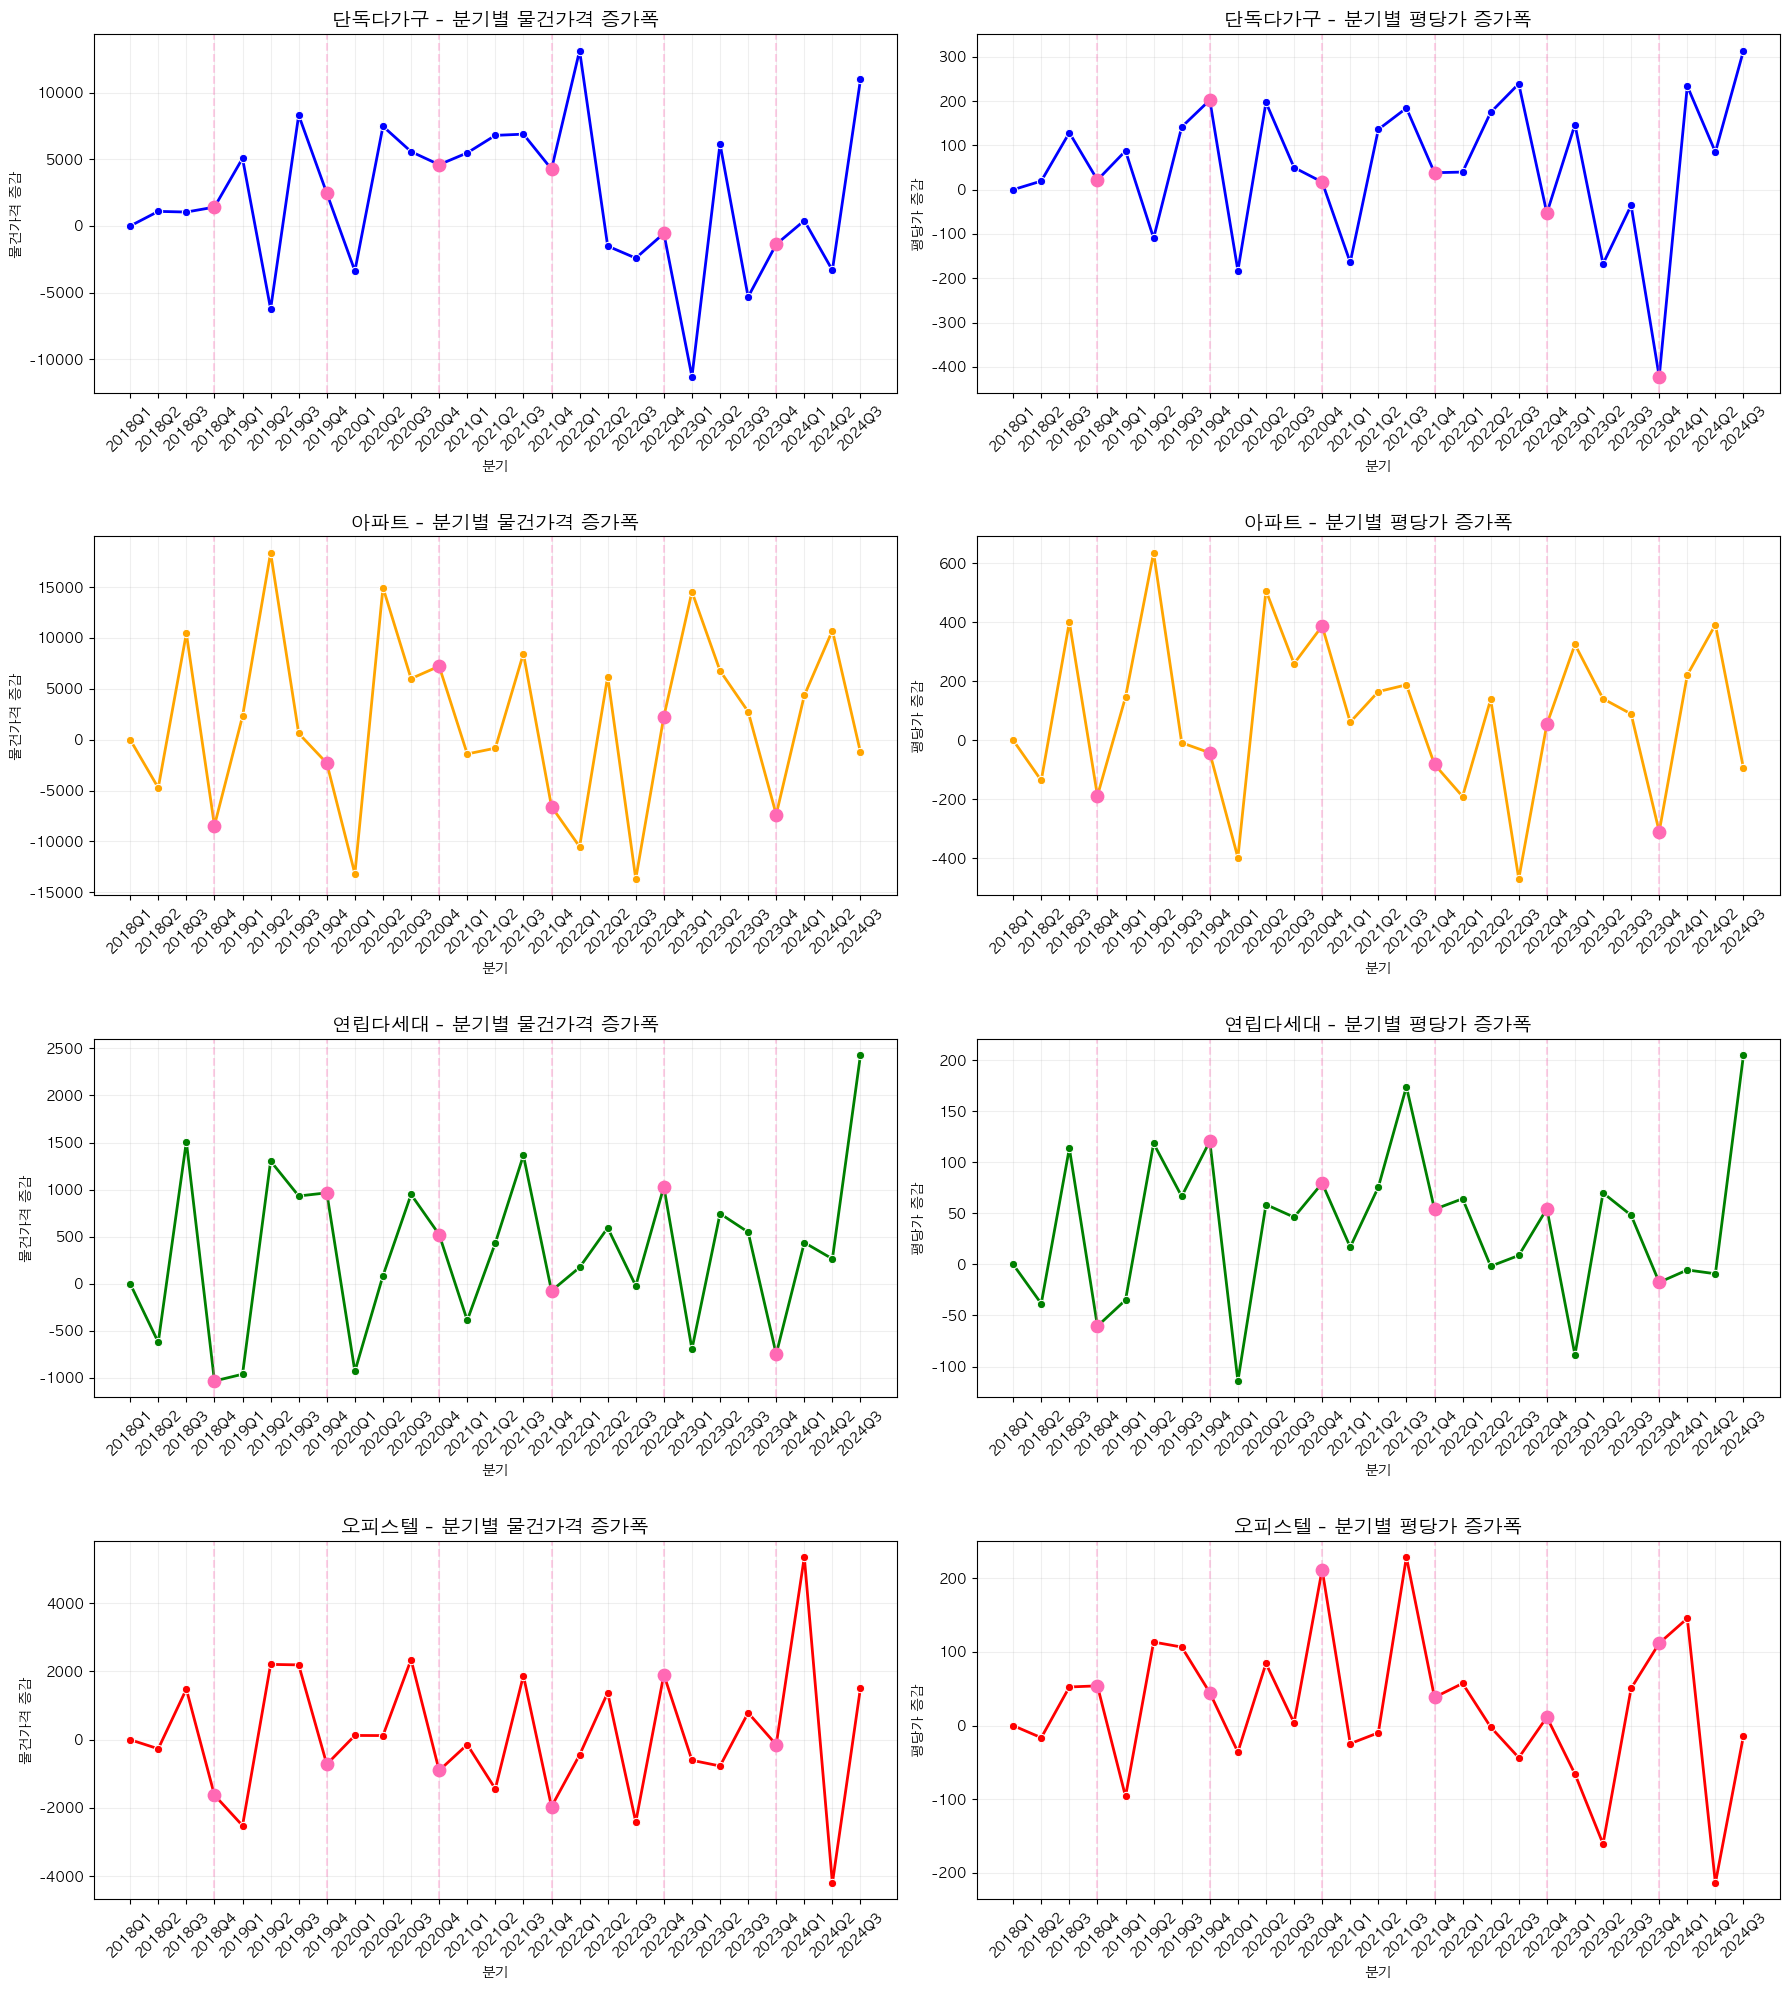

In [ ]:
# 건물가격과 평당가 함께 보기
# 건물용도별 분기별 그래프

# 1. 설정 및 데이터 리스트 준비
plt.rcParams['axes.unicode_minus'] = False 

# 각 행에 들어갈 데이터 (총액 데이터셋, 평당가 데이터셋)
rows_data = [
    (dan, dan2, '단독다가구'),
    (apt, apt2, '아파트'),
    (yeon, yeon2, '연립다세대'),
    (off, off2, '오피스텔')
]
colors = ['blue', 'orange', 'green', 'red']

# 2. 4행 2열 서브플롯 생성
fig, axes = plt.subplots(4, 2, figsize=(18, 20))

for i, (df_total, df_ppp, title) in enumerate(rows_data):
    # 각 행의 두 컬럼 데이터 지정
    sub_data = [(df_total, '물건가격'), (df_ppp, '평당가')]
    
    for j, (dataframe, y_label) in enumerate(sub_data):
        ax = axes[i, j]
        
        # 그래프 그리기
        sns.lineplot(data=dataframe, x='bungi', y='diff', marker='o', 
                     linewidth=2, ax=ax, color=colors[i])
        
        # 4주기(연말) 강조 로직
        for idx, label in enumerate(dataframe['bungi']):
            if label.endswith('Q4'):
                ax.axvline(x=idx, color='hotpink', linestyle='--', alpha=0.3)
                ax.scatter(idx, dataframe['diff'].iloc[idx], color='hotpink', s=80, zorder=5)
        
        # 개별 그래프 설정
        ax.set_title(f"{title} - 분기별 {y_label} 증가폭", fontsize=14, fontweight='bold')
        ax.set_xlabel("분기")
        ax.set_ylabel(f"{y_label} 증감")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, axis='both', alpha=0.2)

# 전체 레이아웃 조정 및 간격 확보
plt.tight_layout()
plt.subplots_adjust(hspace=0.4) # 행 간격 추가
plt.show()

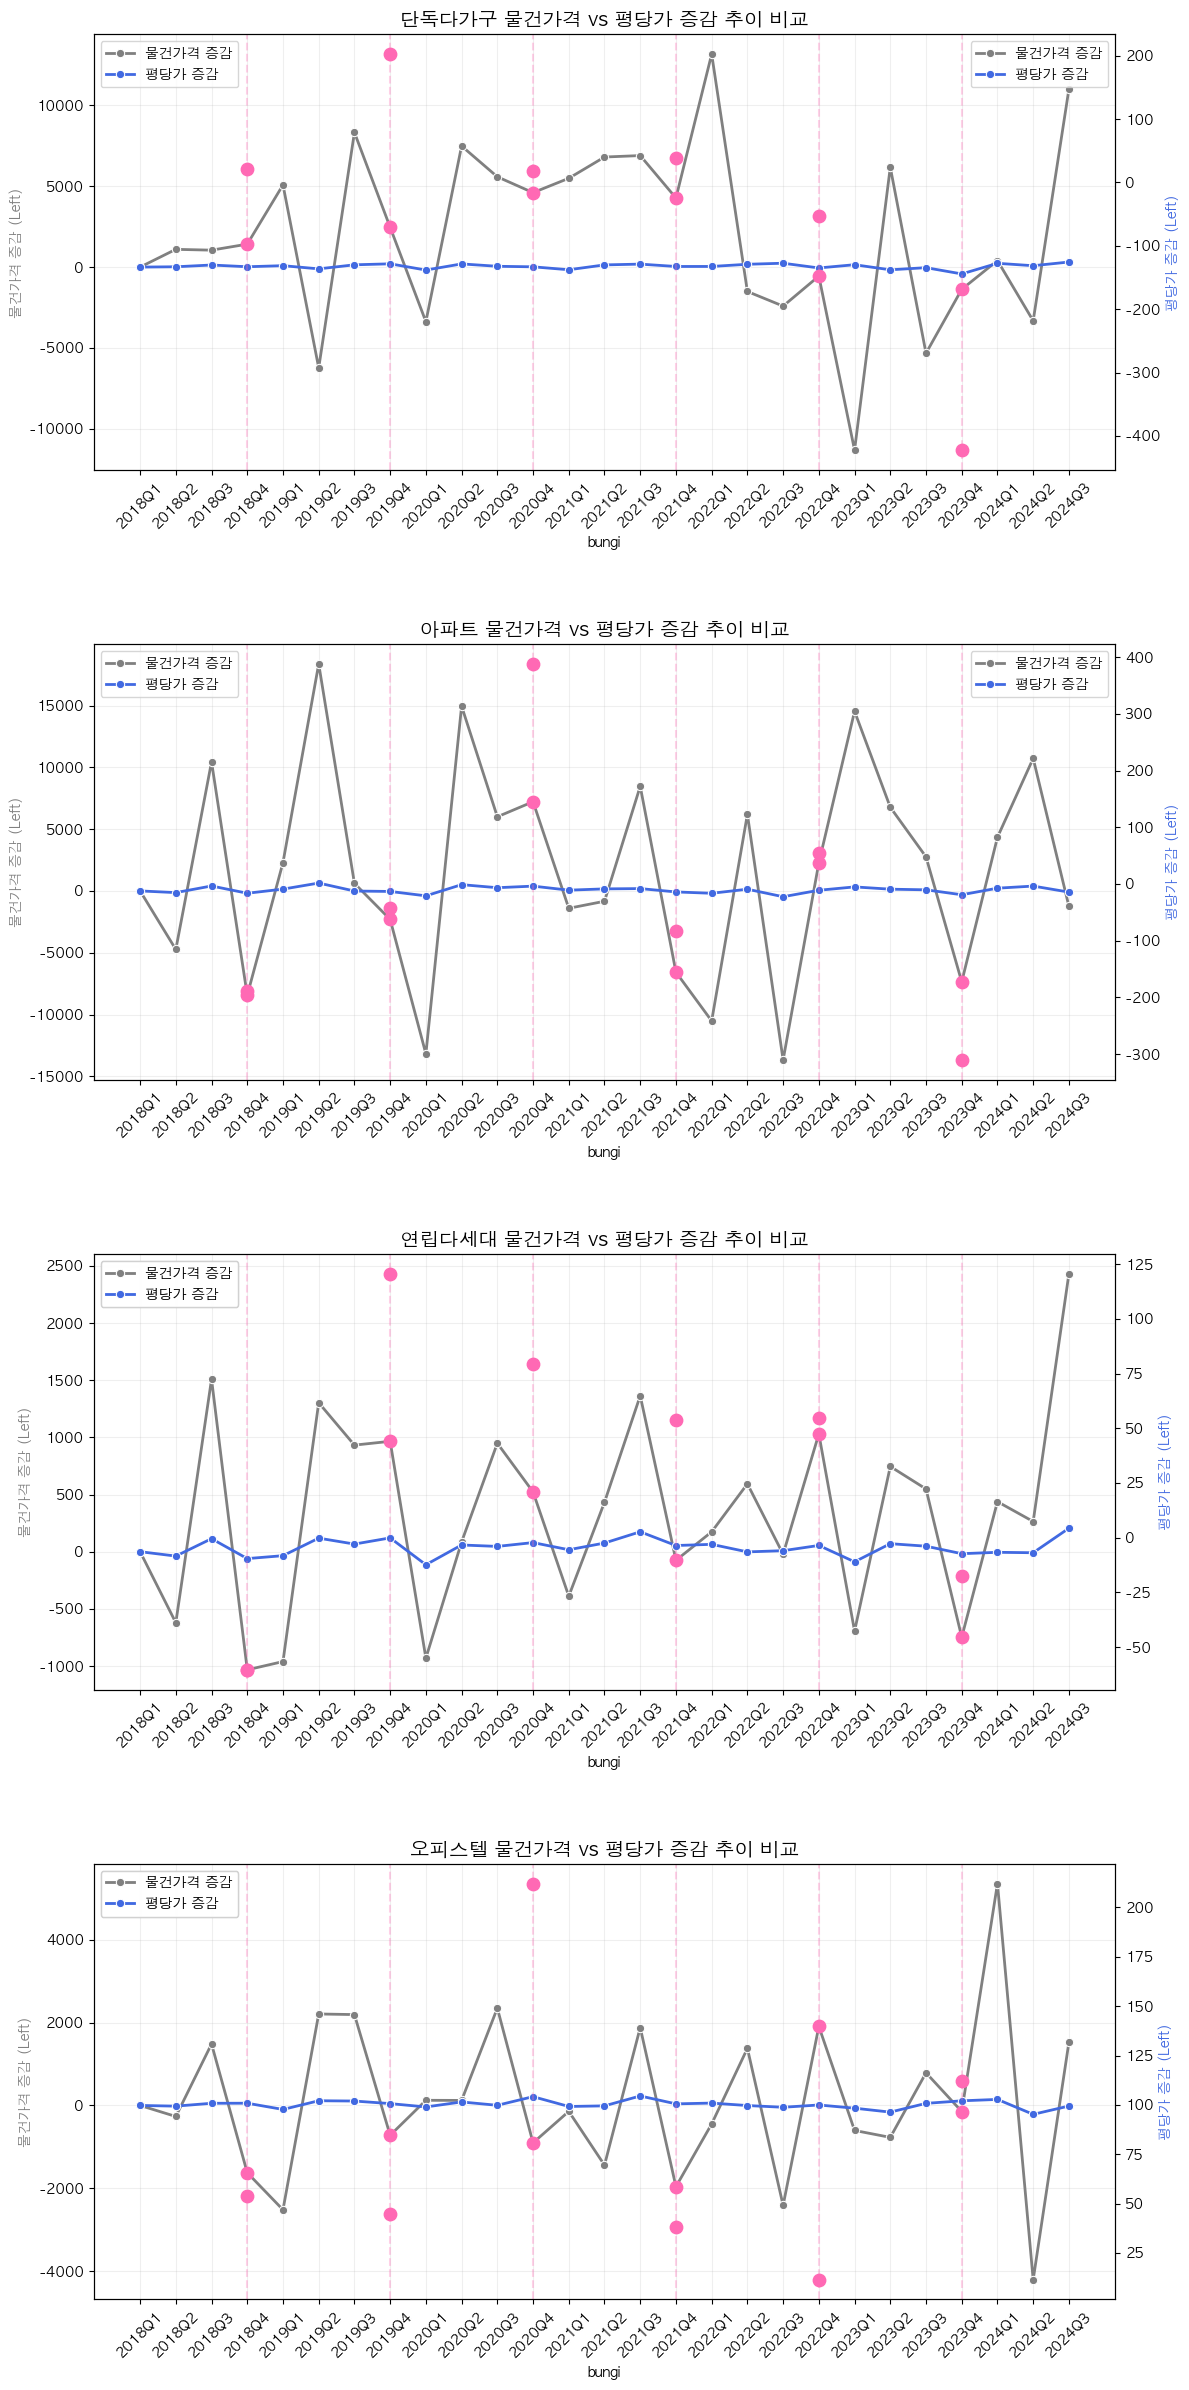

In [ ]:
# 건물가격과 평당가 함께 겹쳐서 보기
# 건물용도별 분기별 그래프

# 1. 설정 및 데이터 리스트 준비
plt.rcParams['axes.unicode_minus'] = False 

# 각 행에 들어갈 데이터 (총액 데이터셋, 평당가 데이터셋)
rows_data = [
    (dan, dan2, '단독다가구'),
    (apt, apt2, '아파트'),
    (yeon, yeon2, '연립다세대'),
    (off, off2, '오피스텔')
]

# 2. 4행 2열 서브플롯 생성
fig, axes = plt.subplots(4, 1, figsize=(12, 24))

for i, (df_total, df_ppp, title) in enumerate(rows_data):

    ax = axes[i]

    # 그래프 그리기
    # --- 왼쪽 Y축: 물건 가격
    sns.lineplot(data=df_total, x='bungi', y='diff', marker='o', 
                    linewidth=2, ax=ax, color='gray', label='물건가격 증감')
    ax.set_ylabel("물건가격 증감 (Left)", color='gray', fontweight='bold')

    # --- 오른쪽 Y축: 평당가
    # ax2는 ax와 x축을 공유하지만 Y축은 오른쪽에 새로 생성
    ax2 = ax.twinx() 
    sns.lineplot(data=df_ppp, x='bungi', y='diff', marker='o', 
                    linewidth=2, ax=ax, color='royalblue', label='평당가 증감')
    ax2.set_ylabel("평당가 증감 (Left)", color='royalblue', fontweight='bold')
    
    # 4주기(연말) 강조 로직
    for idx, label in enumerate(df_total['bungi']):
        if label.endswith('Q4'):
            ax.axvline(x=idx, color='hotpink', linestyle='--', alpha=0.3)
            ax.scatter(idx, df_total['diff'].iloc[idx], color='hotpink', s=80, zorder=5)
            ax2.scatter(idx, df_ppp['diff'].iloc[idx], color='hotpink', s=80, zorder=5)
    
    # 개별 그래프 설정
    ax.set_title(f"{title} 물건가격 vs 평당가 증감 추이 비교", fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='both', alpha=0.2)
    
    # 범례 합치기 (두 축의 범례를 하나로 모으는 팁)
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')
        

# 전체 레이아웃 조정 및 간격 확보
plt.tight_layout()
plt.subplots_adjust(hspace=0.4) # 행 간격 추가
plt.show()

In [ ]:
df.head()

,Unnamed: 0,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,bungi,bungi_int,unit_price
0,14,11530,구로구,10800,오류동,NaN,2018-12-31,73000,197.40,146.0,NaN,NaN,1990,단독다가구,NaN,2018,2018Q4,12,1222.509625
1,16,11215,광진구,10100,중곡동,NaN,2018-12-31,102000,89.09,131.2,NaN,NaN,1973,단독다가구,NaN,2018,2018Q4,12,3784.842294
2,43,11560,영등포구,10900,영등포동8가,NaN,2018-12-29,88700,36.36,91.6,NaN,NaN,1945,단독다가구,NaN,2018,2018Q4,12,8064.479098
3,87,11230,동대문구,10900,휘경동,NaN,2018-12-28,95000,140.22,112.0,NaN,NaN,1991,단독다가구,NaN,2018,2018Q4,12,2239.701897
4,92,11620,관악구,10200,신림동,NaN,2018-12-27,56500,179.46,127.0,NaN,NaN,1988,단독다가구,NaN,2018,2018Q4,12,1040.776218


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777307 entries, 0 to 777306
Data columns (total 19 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  777307 non-null  int64  
 1   CGG_CD      777307 non-null  int64  
 2   CGG_NM      777307 non-null  object 
 3   STDG_CD     777307 non-null  int64  
 4   STDG_NM     777307 non-null  object 
 5   BLDG_NM     724951 non-null  object 
 6   CTRT_DAY    777307 non-null  object 
 7   THING_AMT   777307 non-null  int64  
 8   ARCH_AREA   777307 non-null  float64
 9   LAND_AREA   617714 non-null  float64
 10  FLR         725003 non-null  float64
 11  RGHT_SE     2374 non-null    object 
 12  ARCH_YR     777307 non-null  int64  
 13  BLDG_USG    777307 non-null  object 
 14  DCLR_SE     206848 non-null  object 
 15  CTRT_YEAR   777307 non-null  int64  
 16  bungi       777307 non-null  object 
 17  bungi_int   777307 non-null  int64  
 18  unit_price  777307 non-null  float64
dtypes:

In [ ]:
# 1. 자치구별, 건물용도별 거래 건수 계산 (DataFrame 형태로 변환)
usg_cgg = df.groupby(['CGG_NM', 'BLDG_USG']).size().reset_index(name='count')

# 2. 자치구별(CGG_NM) 총 거래량 계산 후 비율(ratio) 열 생성
# transform('sum')은 각 CGG_NM 그룹 내의 count 합계를 구해서 행마다 분배함
usg_cgg['ratio'] = usg_cgg['count'] / usg_cgg.groupby('CGG_NM')['count'].transform('sum')

# 3. (선택) 퍼센트 형식으로 보기 좋게 정리
usg_cgg['ratio_pct'] = (usg_cgg['ratio'] * 100).round(2)

# ratio 열 삭제
usg_cgg = usg_cgg.drop(columns=['ratio'])

# usg_cgg[usg_cgg['ratio_pct']>=20]
usg_cgg

,CGG_NM,BLDG_USG,count,ratio_pct
0,강남구,단독다가구,776,2.50
1,강남구,아파트,17125,55.27
2,강남구,연립다세대,5923,19.11
3,강남구,오피스텔,7163,23.12
4,강동구,단독다가구,1978,5.24
...,...,...,...,...
95,중구,오피스텔,2016,19.86
96,중랑구,단독다가구,3555,12.56
97,중랑구,아파트,12251,43.28
98,중랑구,연립다세대,11520,40.70


- 자치구별로 가장 핵심 건물 용도를 찾아서 그 건물용도의 추이와 비교해보려고 했는데
- 결국 단독다가구가 비율을 크게 차지하는 자치구는 단 한 건도 없고,
- 대부분 아파트, 연립다세대가 주를 이루기 때문에 이렇게 분류를 하는 것은 적절한 분석이 되지 않음

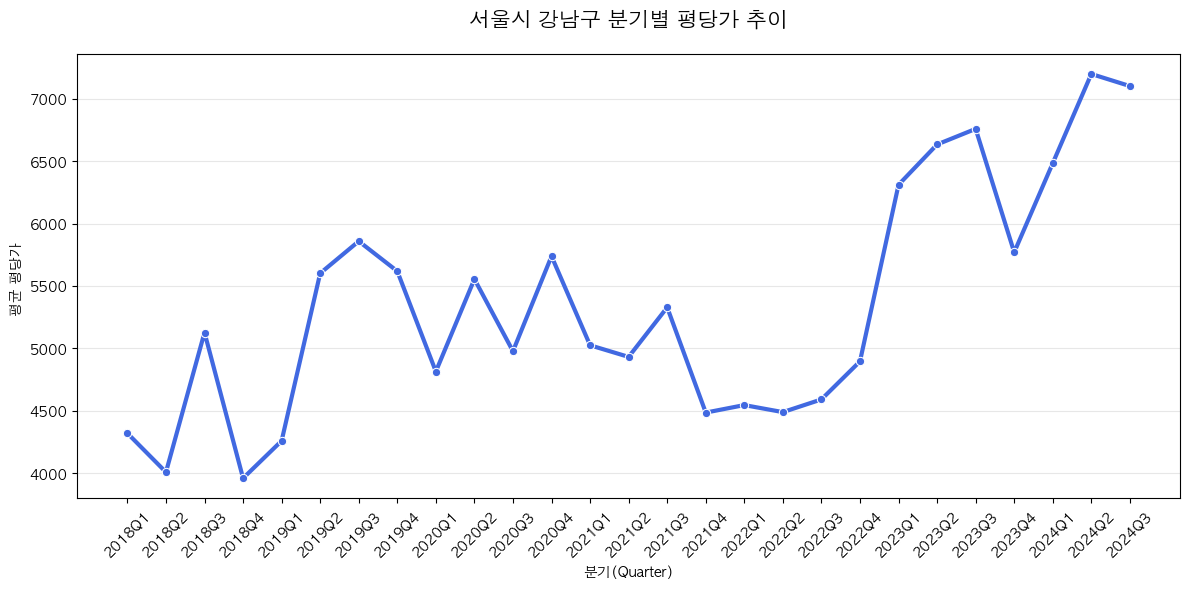

In [ ]:
def plot_gu_price_trend(dfm, gu_name):
    """
    특정 자치구의 분기별 평당가 추이를 시각화하는 함수
    """
    # 1. 해당 자치구 데이터 필터링
    gu_dfm = dfm[dfm['CGG_NM'] == gu_name].copy()
    
    # 데이터가 비어있는 경우 예외 처리
    if gu_dfm.empty:
        print(f"Error: '{gu_name}'에 해당하는 데이터가 없습니다. 구 이름을 확인해주세요.")
        return

    # 2. 분기별 평당가 평균 계산
    trend_dfm = gu_dfm.groupby('bungi')['unit_price'].mean().reset_index()

    # 3. 시각화
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=trend_dfm, x='bungi', y='unit_price', marker='o', 
                 linewidth=3, color='royalblue')
    
    # 그래프 스타일링
    plt.title(f"서울시 {gu_name} 분기별 평당가 추이", fontsize=15, pad=20)
    plt.xlabel("분기(Quarter)")
    plt.ylabel("평균 평당가 ")
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 사용 예시:
plot_gu_price_trend(df, '강남구')

In [ ]:
dan.head()

,BLDG_USG,bungi,THING_AMT,diff
0,단독다가구,2018Q1,91660.798444,0.000000
1,단독다가구,2018Q2,92758.539540,1097.741096
2,단독다가구,2018Q3,93805.797301,1047.257761
3,단독다가구,2018Q4,95224.964023,1419.166722
4,단독다가구,2019Q1,100308.318792,5083.354769


In [ ]:
# 건물가격과 평당가 함께 겹쳐서 보기
# 건물용도별 분기별 그래프

# 1. 설정 및 데이터 리스트 준비
plt.rcParams['axes.unicode_minus'] = False 

# 각 행에 들어갈 데이터 (총액 데이터셋, 평당가 데이터셋)
rows_data = [
    (df, dan2, '단독다가구'),
    (df, apt2, '아파트'),
    (df, yeon2, '연립다세대'),
    (df, off2, '오피스텔')
]

# 2. 4행 2열 서브플롯 생성
fig, axes = plt.subplots(4, 1, figsize=(12, 24))

for i, (df_seoul, df_ppp, title) in enumerate(rows_data):

    ax = axes[i]

    # 그래프 그리기
    # --- 왼쪽 Y축: 물건 가격
    sns.lineplot(data=df_seoul, x='bungi', y='', marker='o', 
                    linewidth=2, ax=ax, color='gray', label='물건가격 증감')
    ax.set_ylabel("서울 전체 데이터 평당가 증감 (Left)", color='gray', fontweight='bold')

    # --- 오른쪽 Y축: 평당가
    # ax2는 ax와 x축을 공유하지만 Y축은 오른쪽에 새로 생성
    ax2 = ax.twinx() 
    sns.lineplot(data=df_ppp, x='bungi', y='diff', marker='o', 
                    linewidth=2, ax=ax, color='royalblue', label='평당가 증감')
    ax2.set_ylabel("평당가 증감 (Left)", color='royalblue', fontweight='bold')
    
    # 4주기(연말) 강조 로직
    for idx, label in enumerate(df_seoul['bungi']):
        if label.endswith('Q4'):
            ax.axvline(x=idx, color='hotpink', linestyle='--', alpha=0.3)
            ax.scatter(idx, df_seoul['diff'].iloc[idx], color='hotpink', s=80, zorder=5)
            ax2.scatter(idx, df_ppp['diff'].iloc[idx], color='hotpink', s=80, zorder=5)
    
    # 개별 그래프 설정
    ax.set_title(f"{title} 물건가격 vs 평당가 증감 추이 비교", fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, axis='both', alpha=0.2)
    
    # 범례 합치기 (두 축의 범례를 하나로 모으는 팁)
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')
        

# 전체 레이아웃 조정 및 간격 확보
plt.tight_layout()
plt.subplots_adjust(hspace=0.4) # 행 간격 추가
plt.show()

In [ ]:
def plot_gu_bldg_comparison(dfm, gu_name):
    """
    특정 자치구 내 4대 건물 용도별 평당가(unit_price) 추이 비교
    """
    # 1. 해당 자치구 데이터 필터링 (원본 dfm에서 unit_price가 계산되어 있어야 함)
    gu_dfm = dfm[dfm['CGG_NM'] == gu_name].copy()
    
    if gu_dfm.empty:
        print(f"'{gu_name}' 데이터가 존재하지 않습니다.")
        return

    # 2. 용도별 데이터 분리 및 리스트화
    # 각 용도별로 분기별 평균 평당가 계산
    usg_types = ['단독다가구', '아파트', '연립다세대', '오피스텔']
    colors = ['royalblue', 'darkorange', 'forestgreen', 'crimson']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for i, usg in enumerate(usg_types):
        ax = axes[i]
        # 해당 용도 데이터 추출 및 분기별 평균 계산
        data = gu_dfm[gu_dfm['BLDG_USG'] == usg].groupby('bungi')['unit_price'].mean().reset_index()
        
        if data.empty:
            ax.text(0.5, 0.5, f'{usg} 데이터 없음', ha='center', va='center')
        else:
            sns.lineplot(data=data, x='bungi', y='unit_price', marker='o', 
                         ax=ax, color=colors[i], linewidth=2.5)
            
            # 연말(Q4) 강조 가이드라인
            for idx, label in enumerate(data['bungi']):
                if label.endswith('Q4'):
                    ax.axvline(x=label, color='hotpink', linestyle='--', alpha=0.3)

        ax.set_title(f"{gu_name} {usg} 평당가 추이", fontsize=13, fontweight='bold')
        ax.set_xlabel("분기")
        ax.set_ylabel("평균 평당가 (unit_price)")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.2)

    plt.suptitle(f"[{gu_name}] 건물 용도별 평당가(unit_price) 추이 분석", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

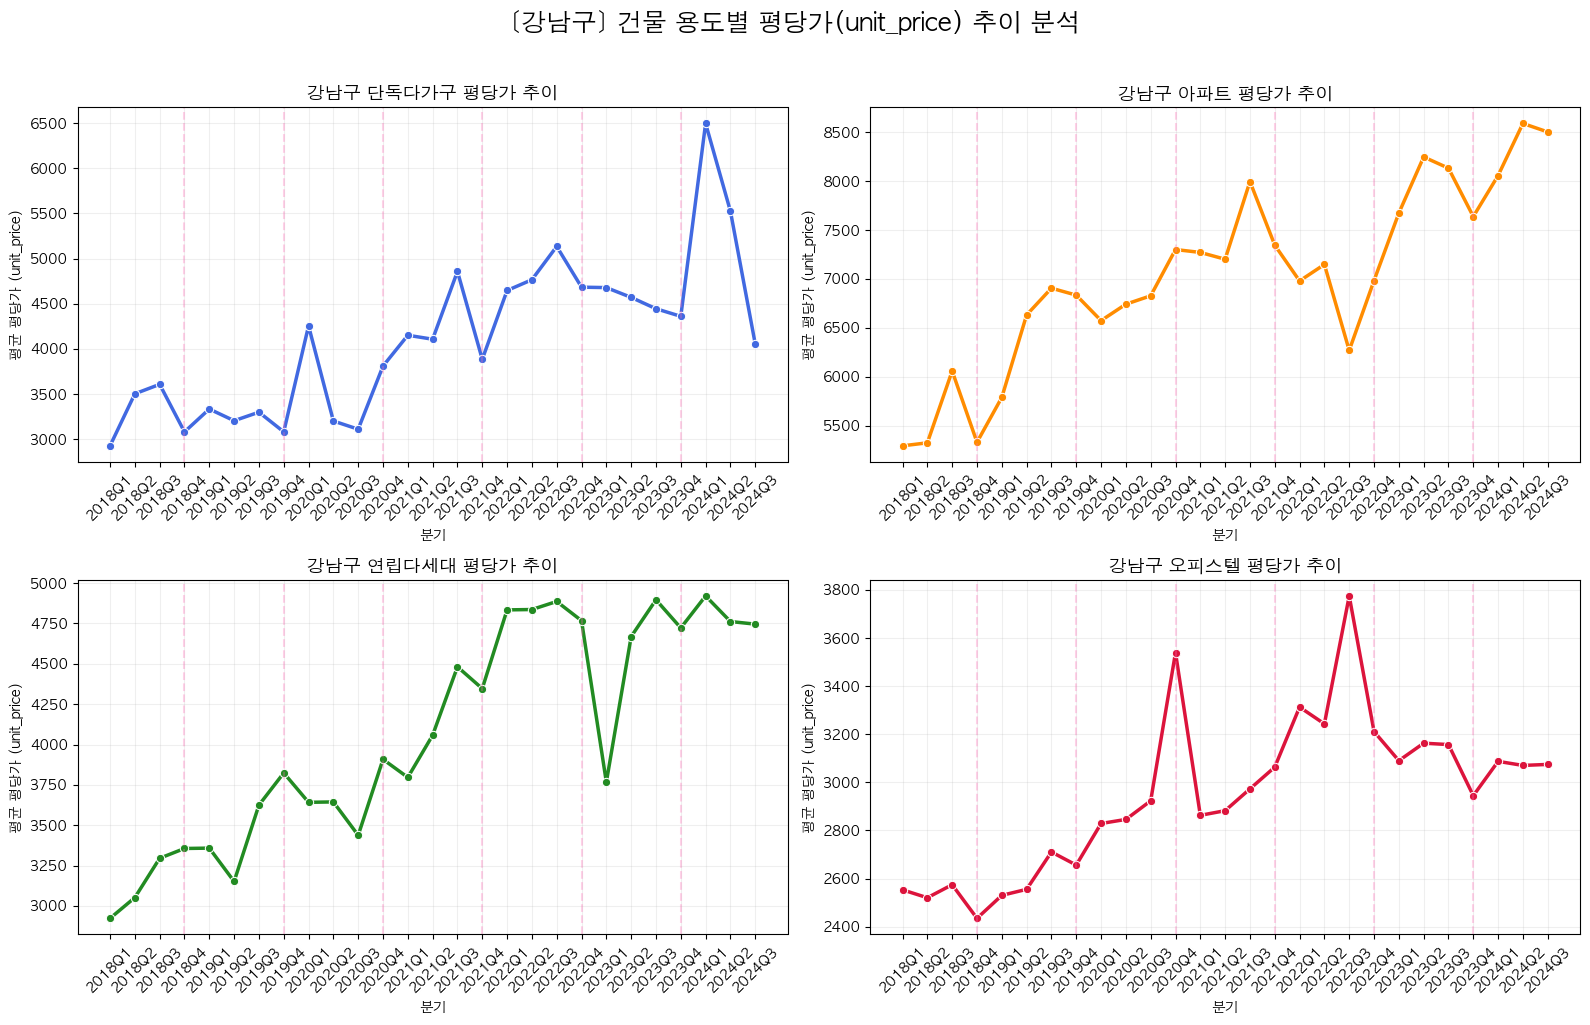

In [ ]:
# 함수 호출 예시
plot_gu_bldg_comparison(df, '강남구')

In [ ]:
import matplotlib.gridspec as gridspec

def plot_gu_master_analysis(dfm, gu_name):
    """
    상단에 자치구 전체 추이, 하단에 4대 용도별 추이를 배치하는 통합 시각화
    """
    gu_dfm = dfm[dfm['CGG_NM'] == gu_name].copy()
    if gu_dfm.empty:
        print(f"'{gu_name}' 데이터가 없습니다.")
        return

    # 1. Figure 및 GridSpec 설정 (3행 2열)
    fig = plt.figure(figsize=(16, 18))
    gs = gridspec.GridSpec(3, 2, figure=fig)
    
    # 2. 상단: 자치구 전체 평균 추이 (첫 번째 행 전체 차지)
    ax_top = fig.add_subplot(gs[0, :])
    total_data = gu_dfm.groupby('bungi')['unit_price'].mean().reset_index()
    sns.lineplot(data=total_data, x='bungi', y='unit_price', marker='o', 
                 ax=ax_top, color='black', linewidth=3, label='자치구 전체 평균')
    
    ax_top.set_title(f"[{gu_name}] 전체 분기별 평당가(unit_price) 추이", fontsize=16, fontweight='bold')
    ax_top.set_ylabel("평균 평당가")
    ax_top.grid(True, alpha=0.3)

    # 3. 하단: 용도별 4개 그래프
    usg_types = ['단독다가구', '아파트', '연립다세대', '오피스텔']
    colors = ['royalblue', 'darkorange', 'forestgreen', 'crimson']
    
    # 각 용도가 들어갈 위치 설정 (2행 0열, 2행 1열, 3행 0열, 3행 1열)
    positions = [(1, 0), (1, 1), (2, 0), (2, 1)]

    for i, usg in enumerate(usg_types):
        ax = fig.add_subplot(gs[positions[i]])
        data = gu_dfm[gu_dfm['BLDG_USG'] == usg].groupby('bungi')['unit_price'].mean().reset_index()
        
        if not data.empty:
            sns.lineplot(data=data, x='bungi', y='unit_price', marker='o', 
                         ax=ax, color=colors[i], linewidth=2)
            
            # Q4 수직선 강조
            for idx, label in enumerate(data['bungi']):
                if label.endswith('Q4'):
                    ax.axvline(x=label, color='hotpink', linestyle='--', alpha=0.3)
        
        ax.set_title(f"{usg} 추이", fontsize=13)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.2)

    plt.suptitle(f"{gu_name} 부동산 시장 심층 분석 (Total & Usage)", fontsize=22, y=1.02)
    plt.tight_layout()
    plt.show()


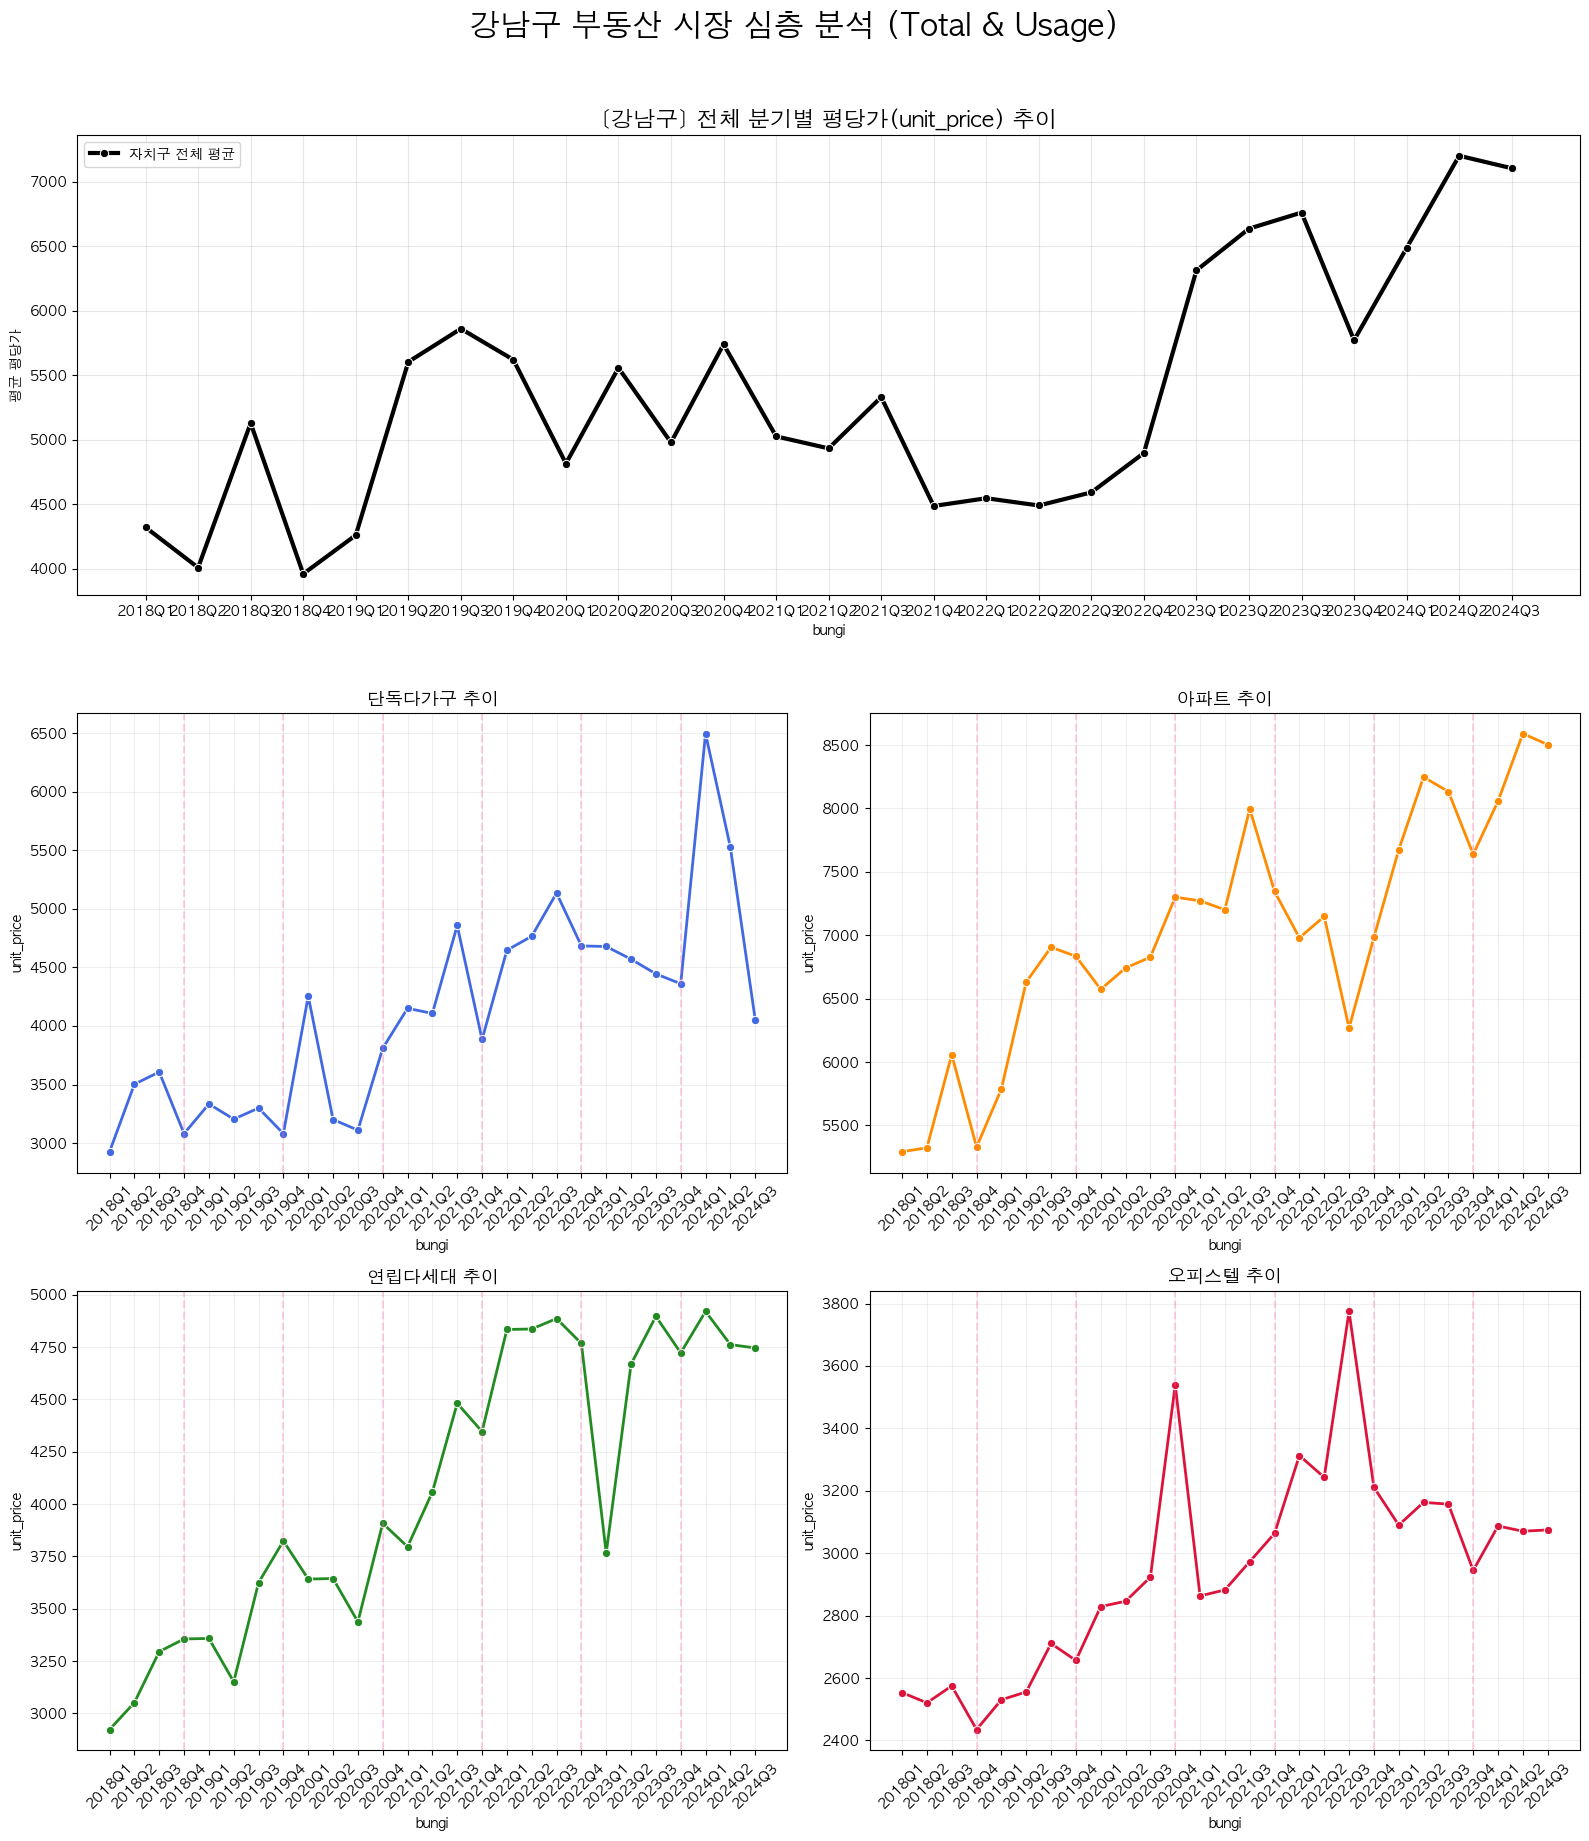

In [ ]:
# 실행 강남구
plot_gu_master_analysis(df, '강남구')

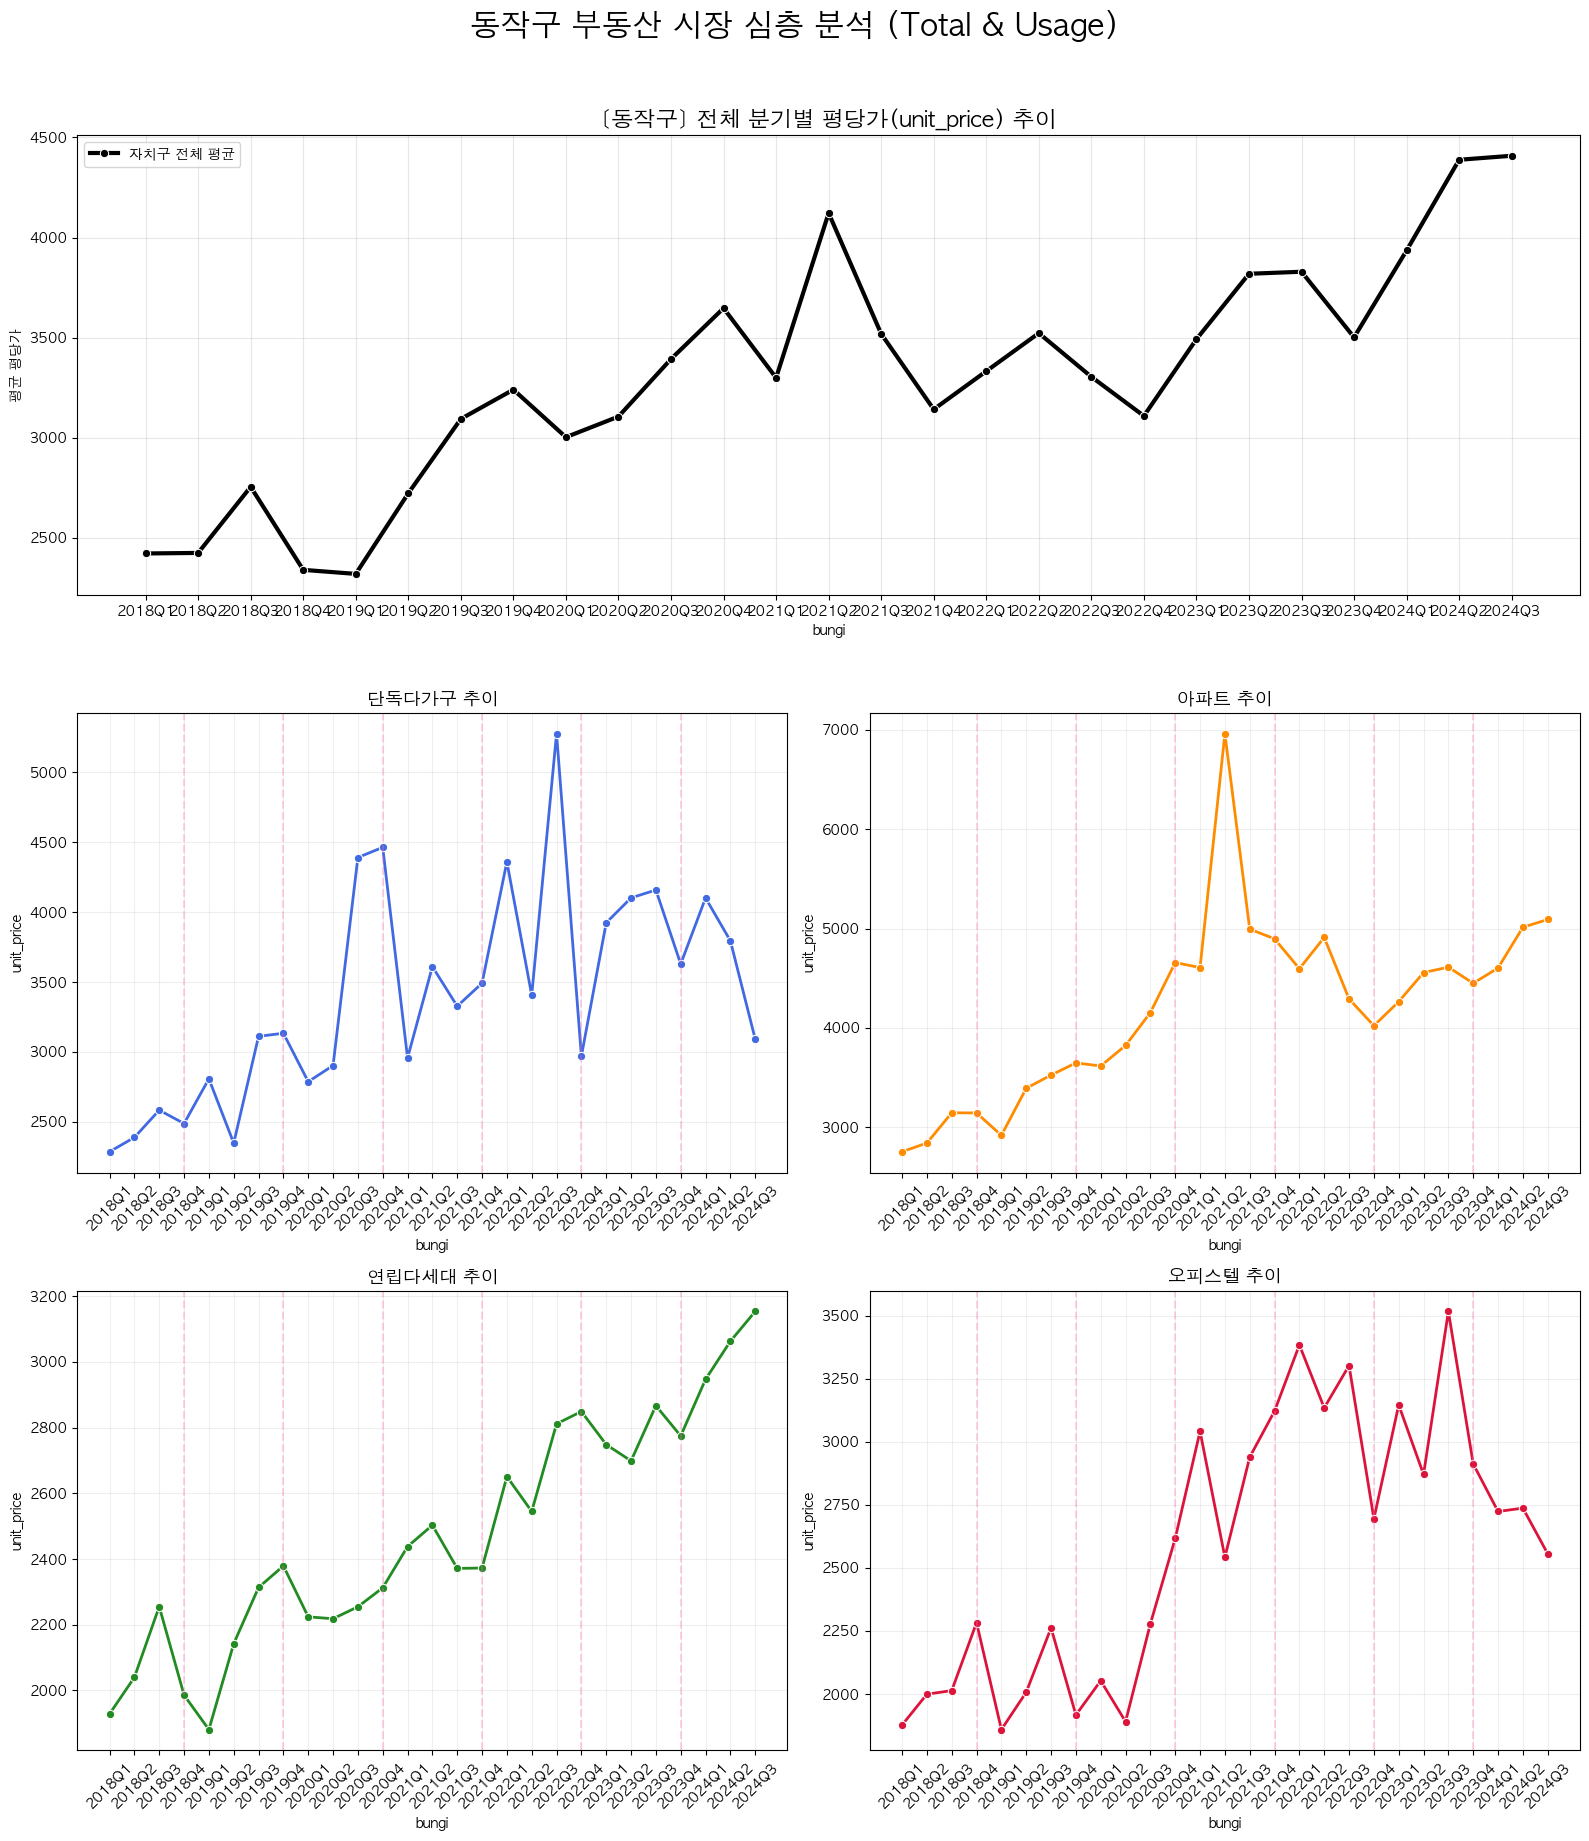

In [ ]:
# 실행 동작구
plot_gu_master_analysis(df, '동작구')

In [ ]:
df['CGG_NM'].value_counts()

CGG_NM
강서구     58673
은평구     48247
송파구     47614
노원구     42880
구로구     38654
강동구     37770
성북구     36499
양천구     36430
마포구     33375
영등포구    31968
강남구     30987
도봉구     30786
관악구     30612
중랑구     28305
동대문구    28201
동작구     28192
강북구     27595
서초구     26831
서대문구    25721
광진구     23292
금천구     23233
성동구     21453
용산구     18195
종로구     11642
중구      10152
Name: count, dtype: int64

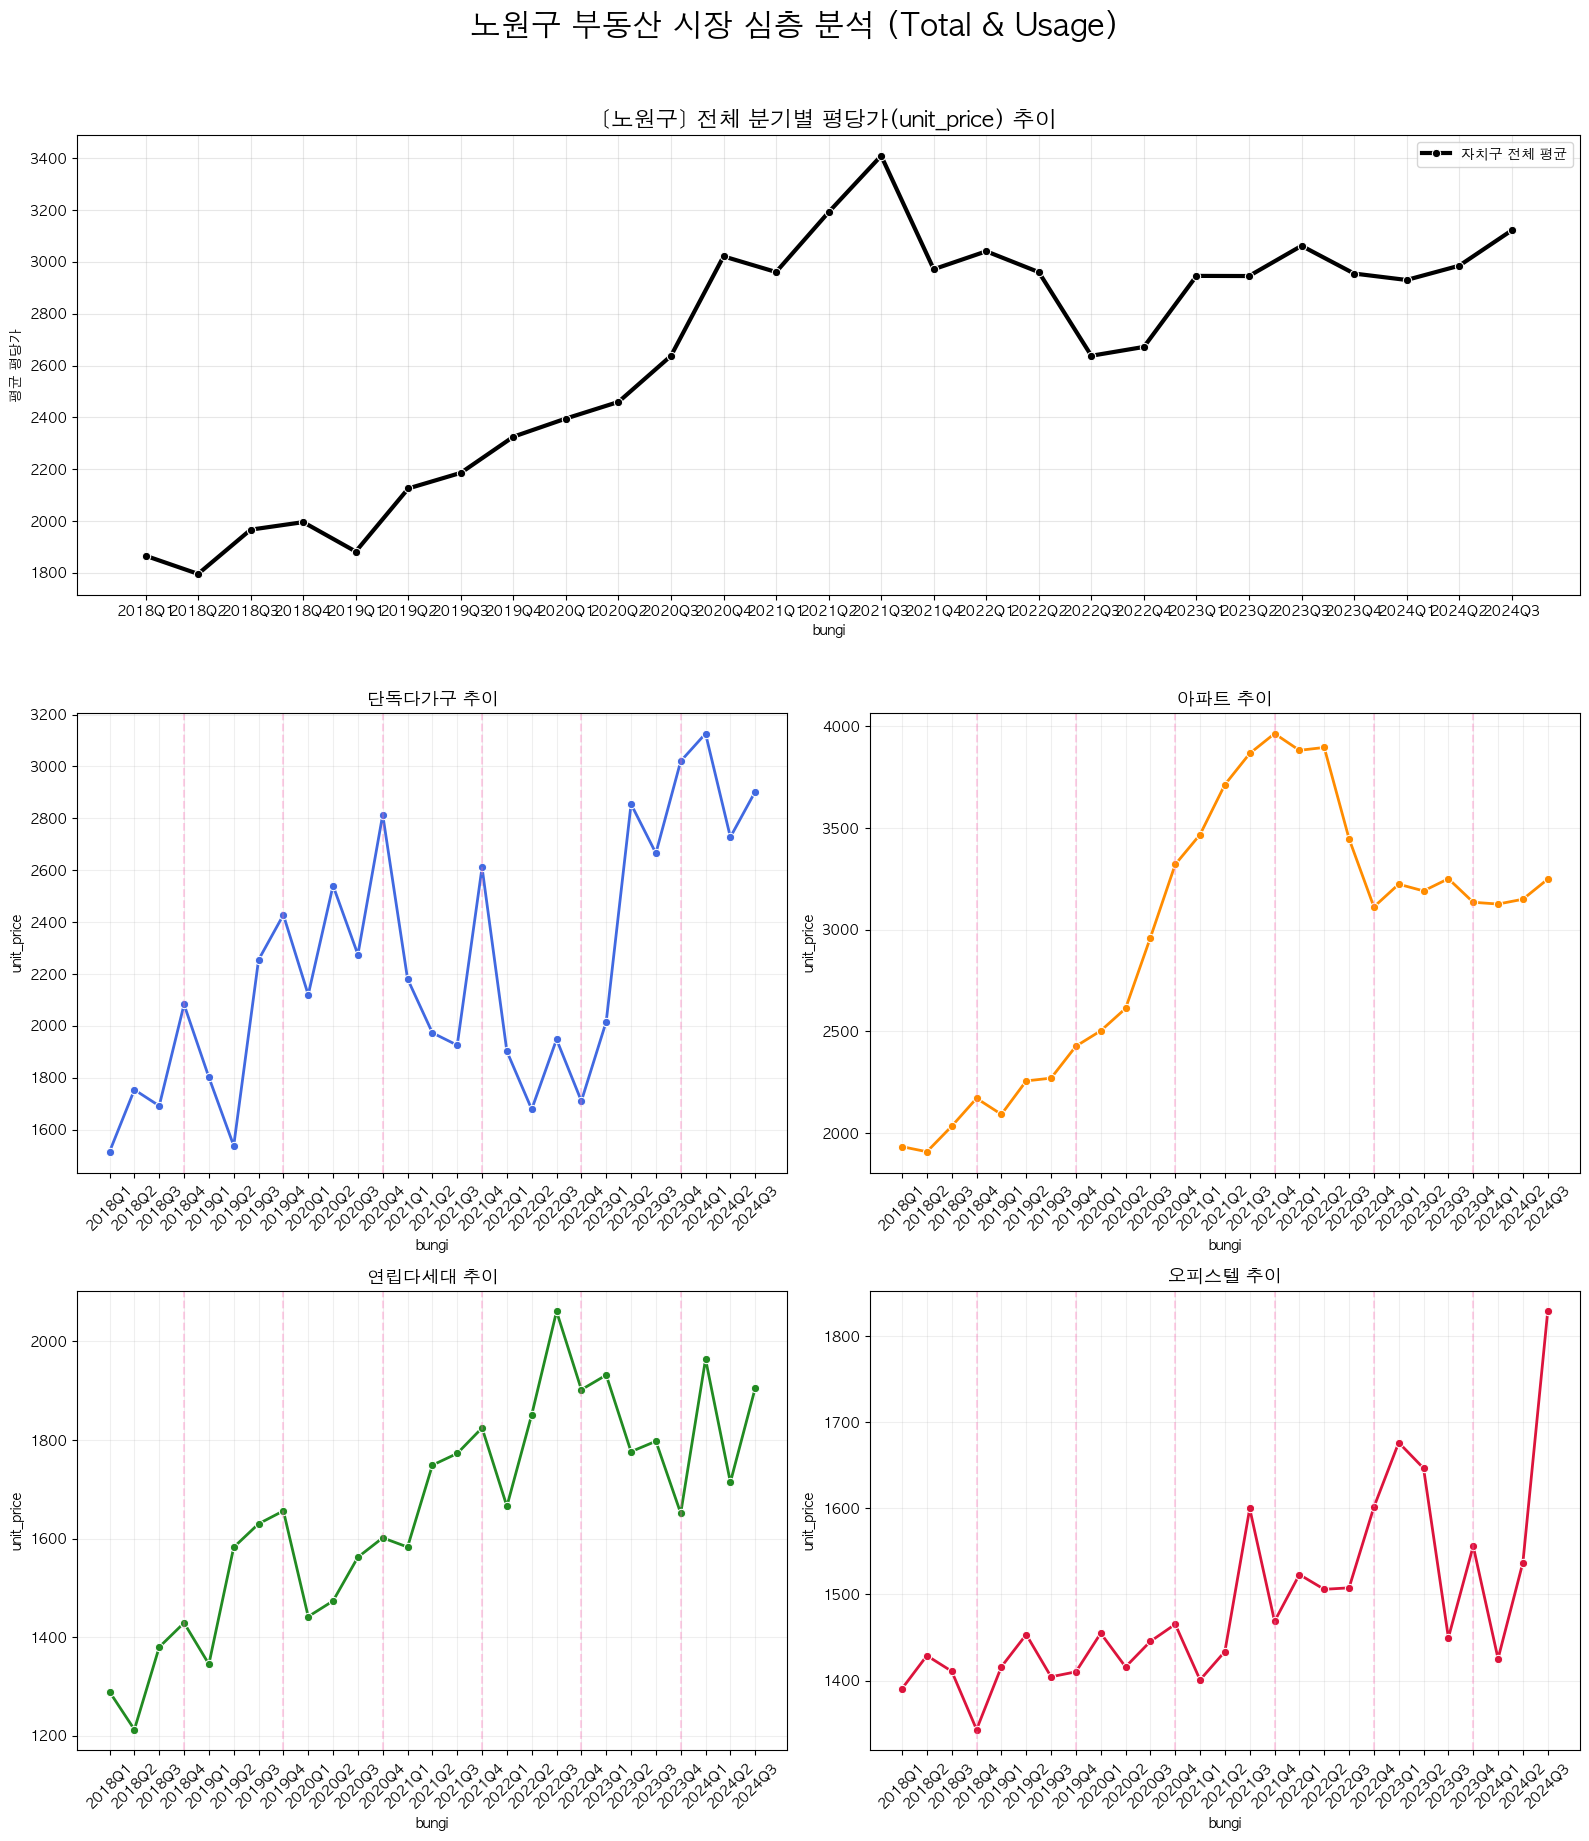

In [ ]:
# 실행 노원구
plot_gu_master_analysis(df, '노원구')

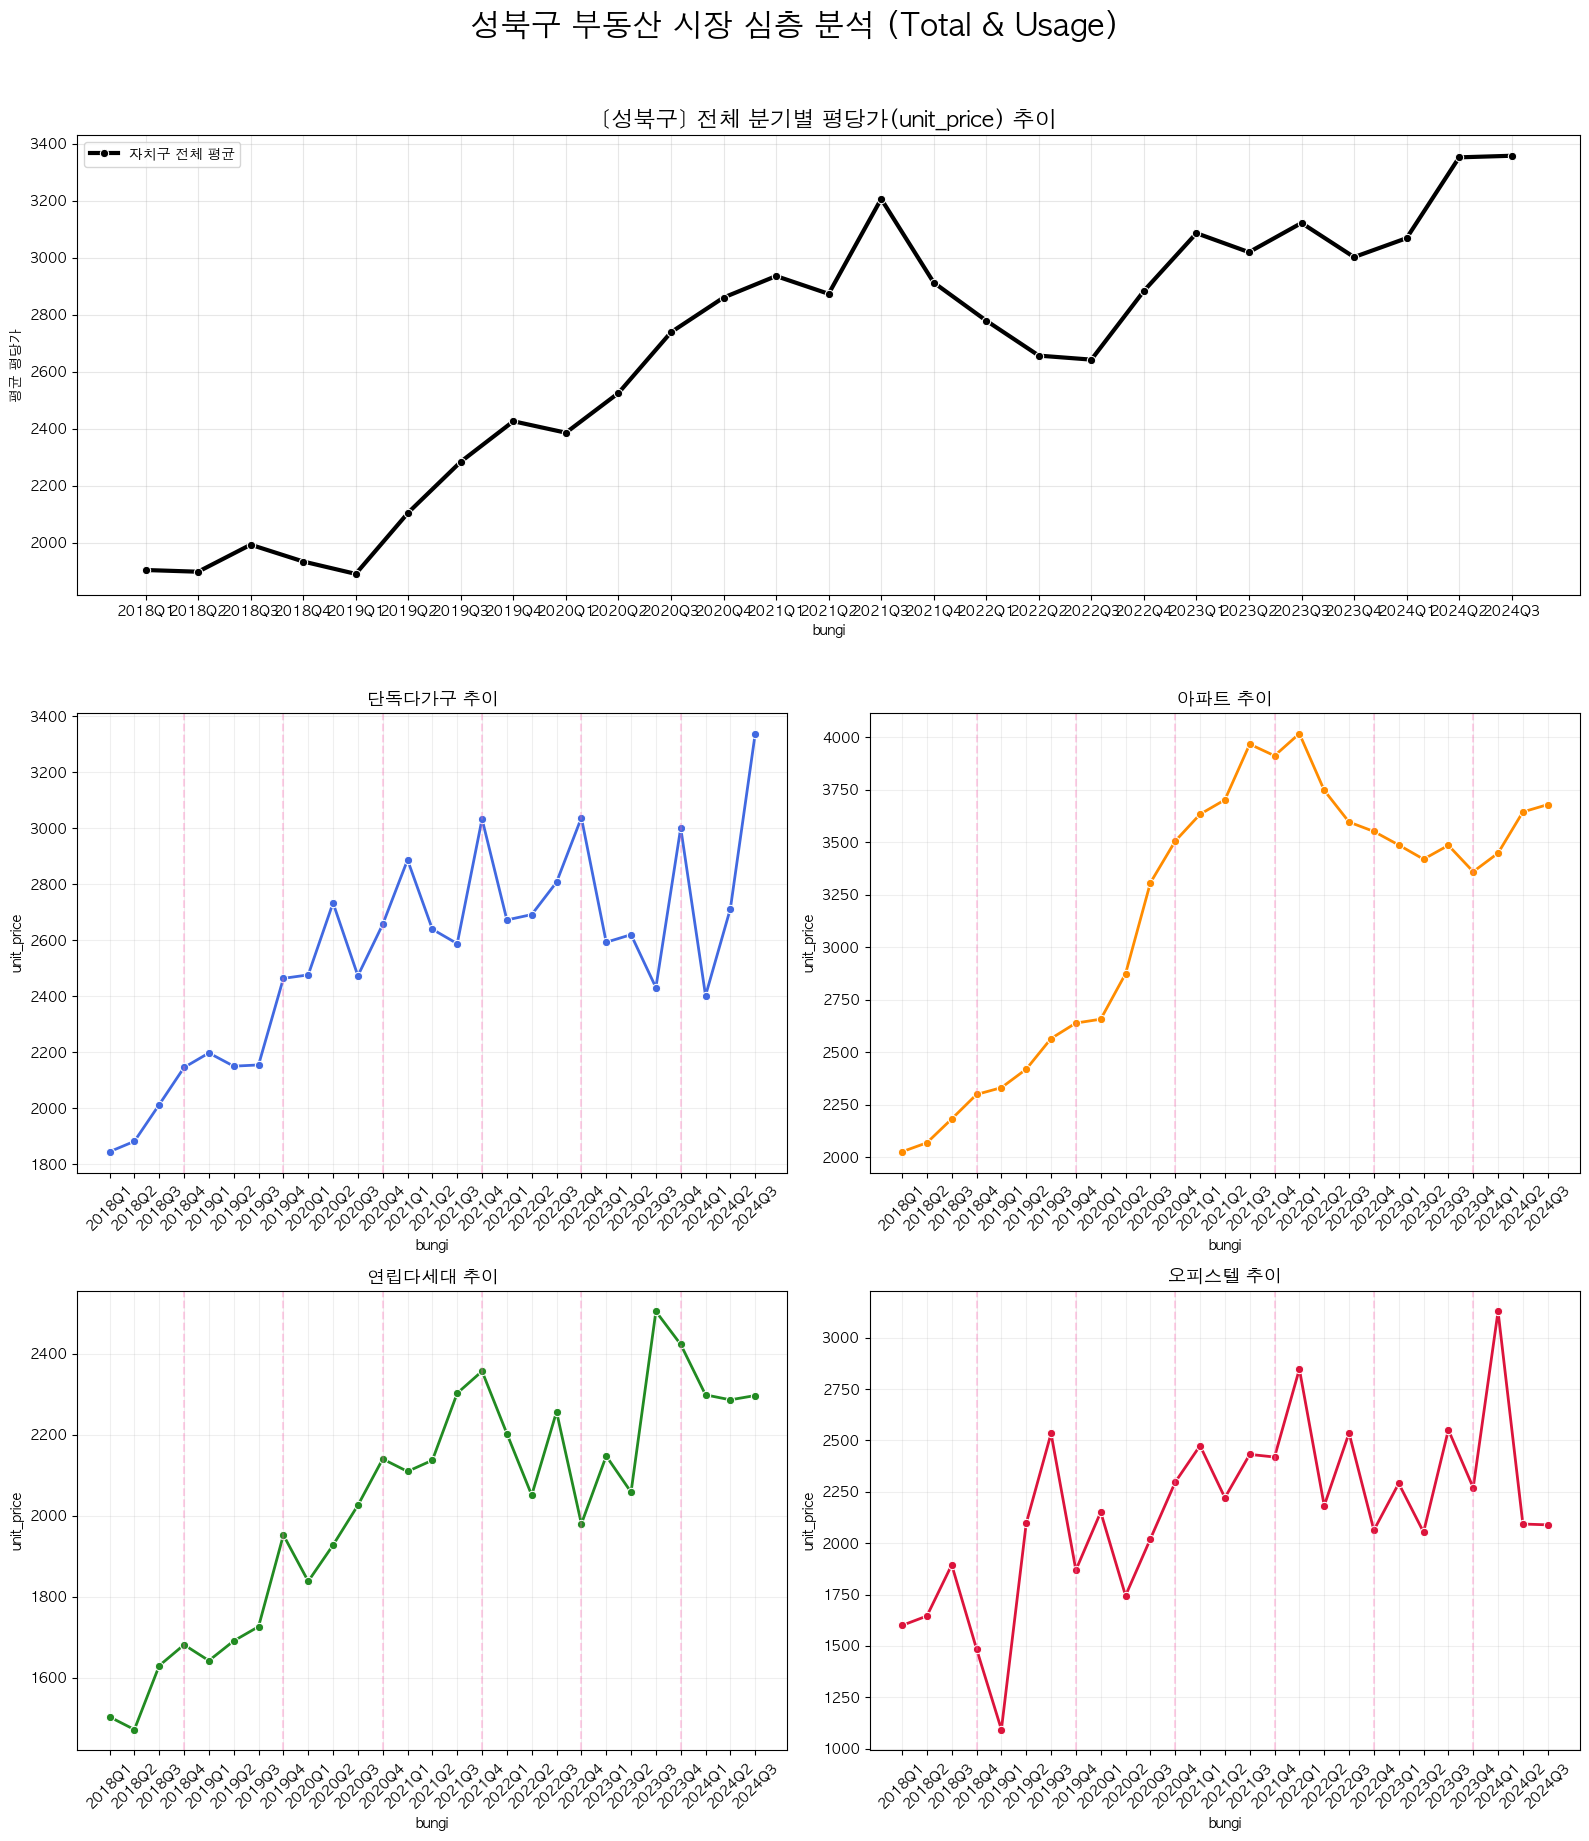

In [ ]:
# 실행 성북구
plot_gu_master_analysis(df, '성북구')

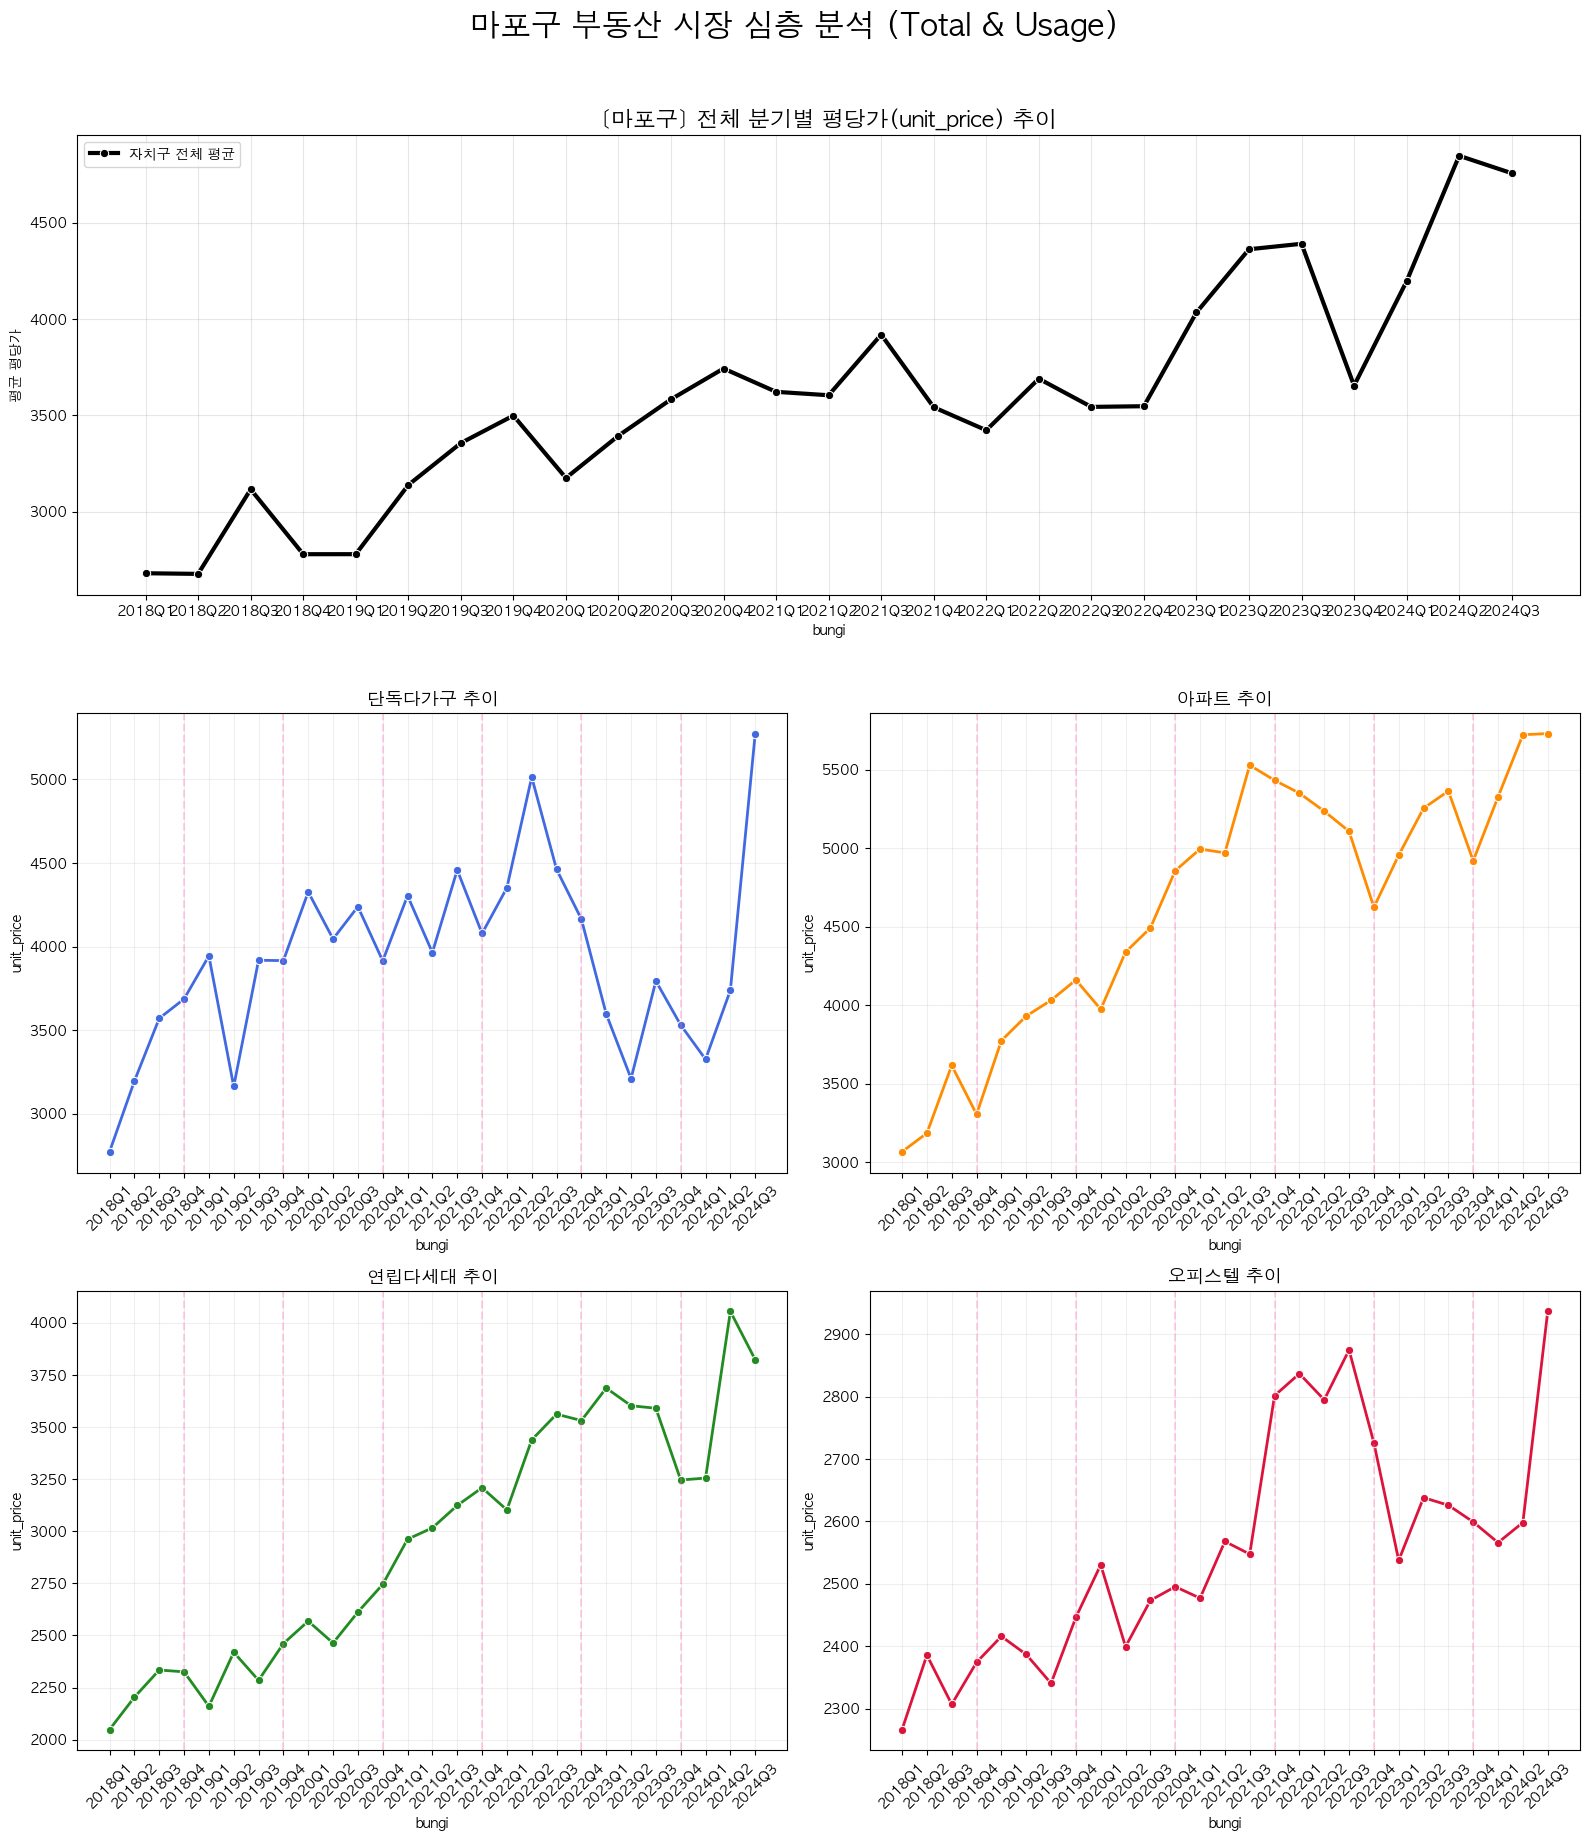

In [ ]:
# 실행 마포구
plot_gu_master_analysis(df, '마포구')

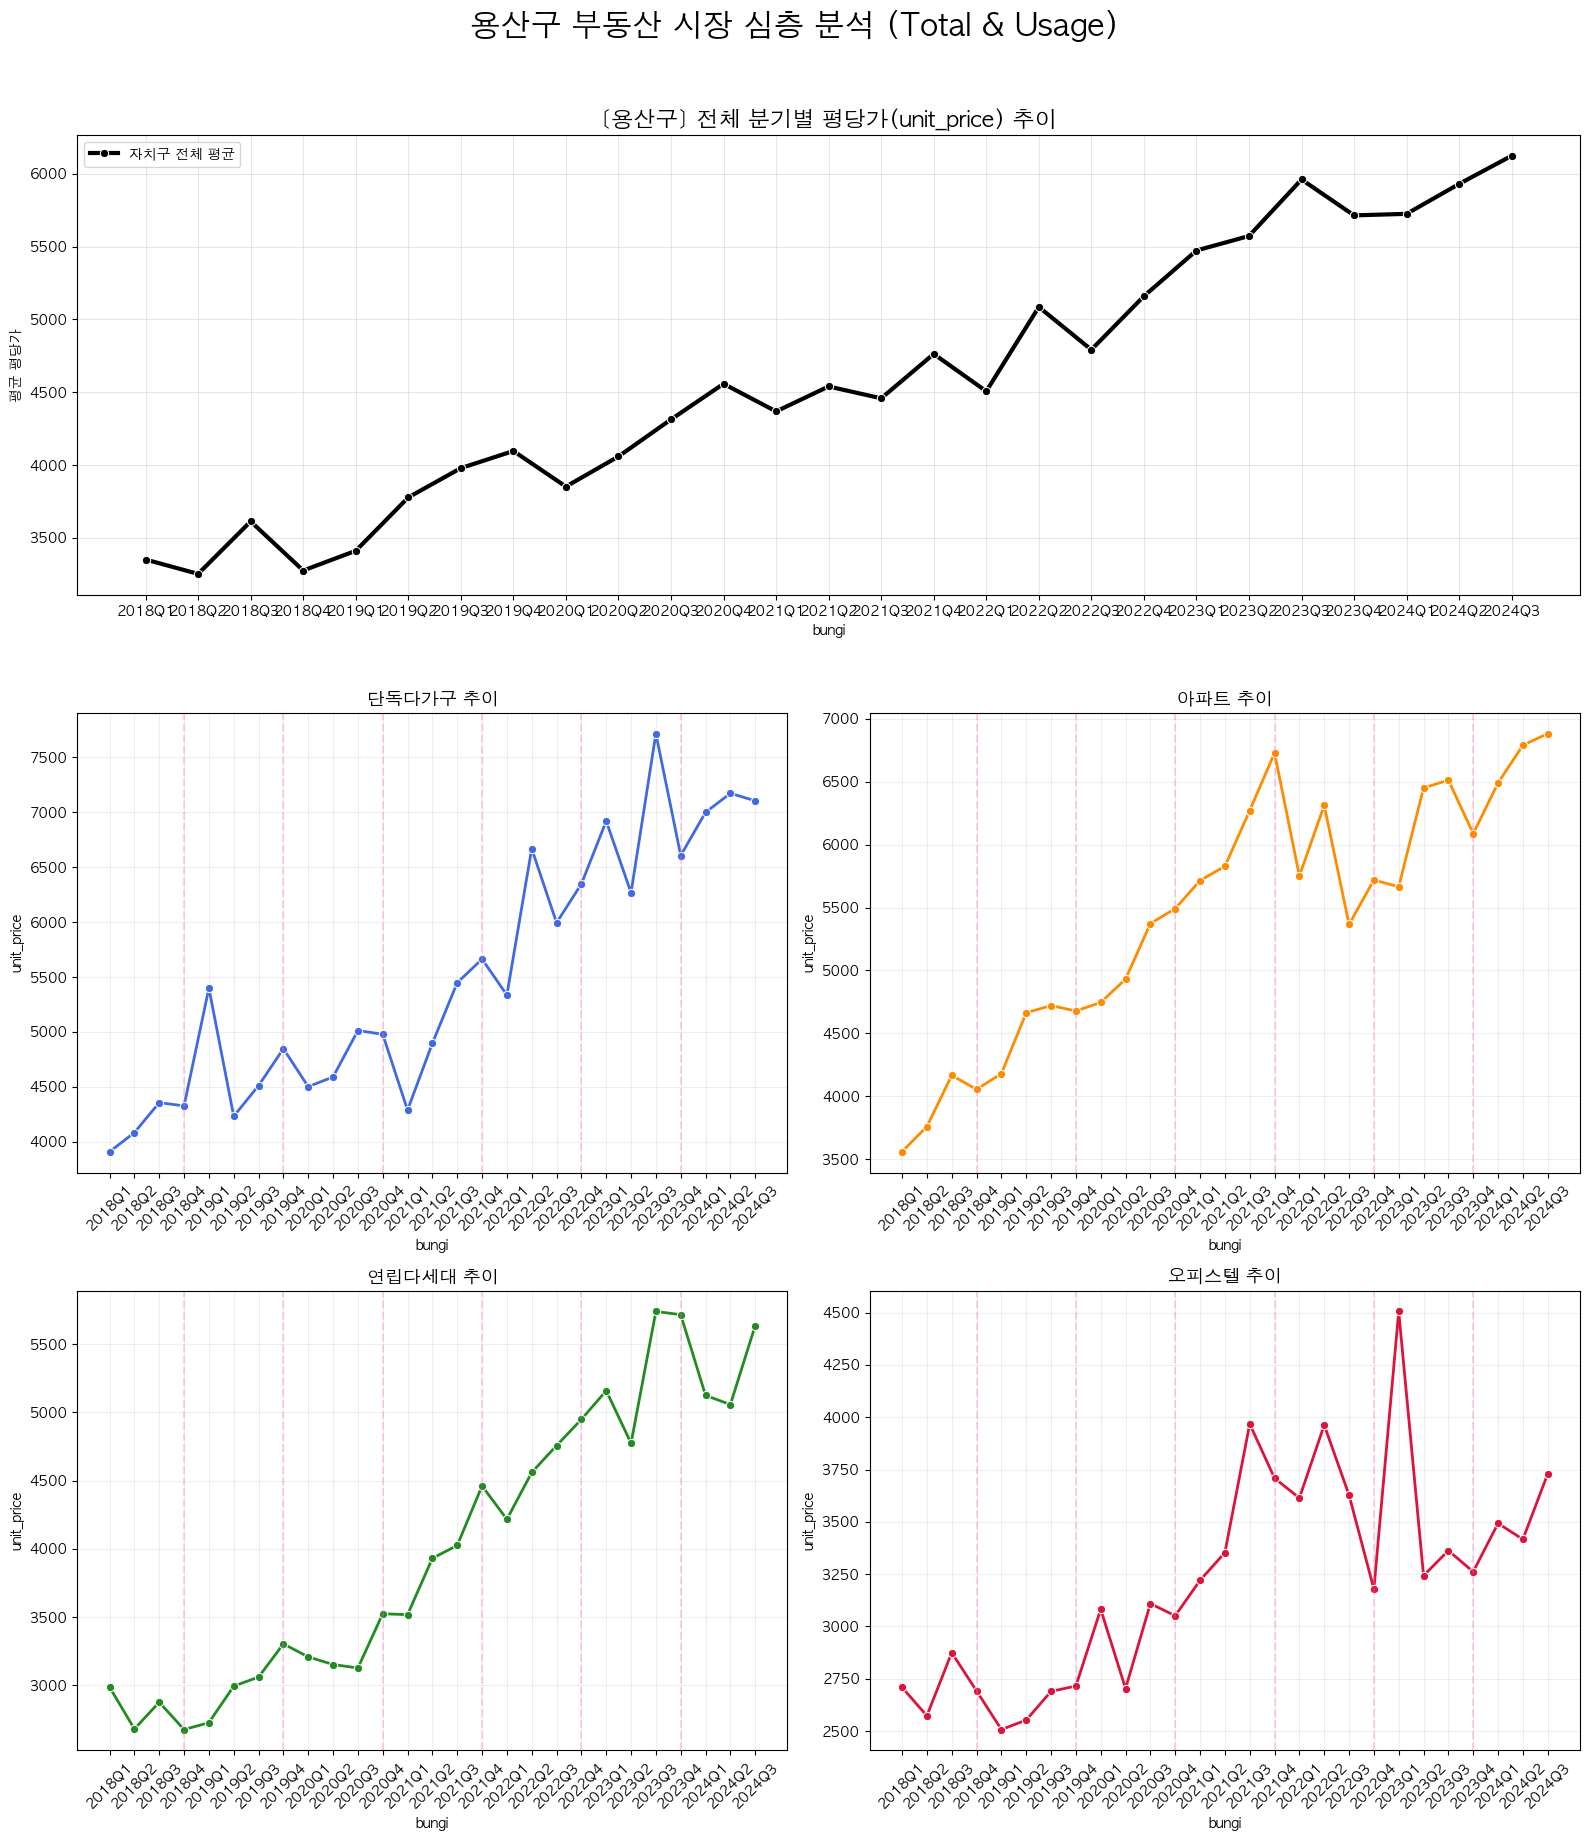

In [ ]:
# 실행 용산구
plot_gu_master_analysis(df, '용산구')

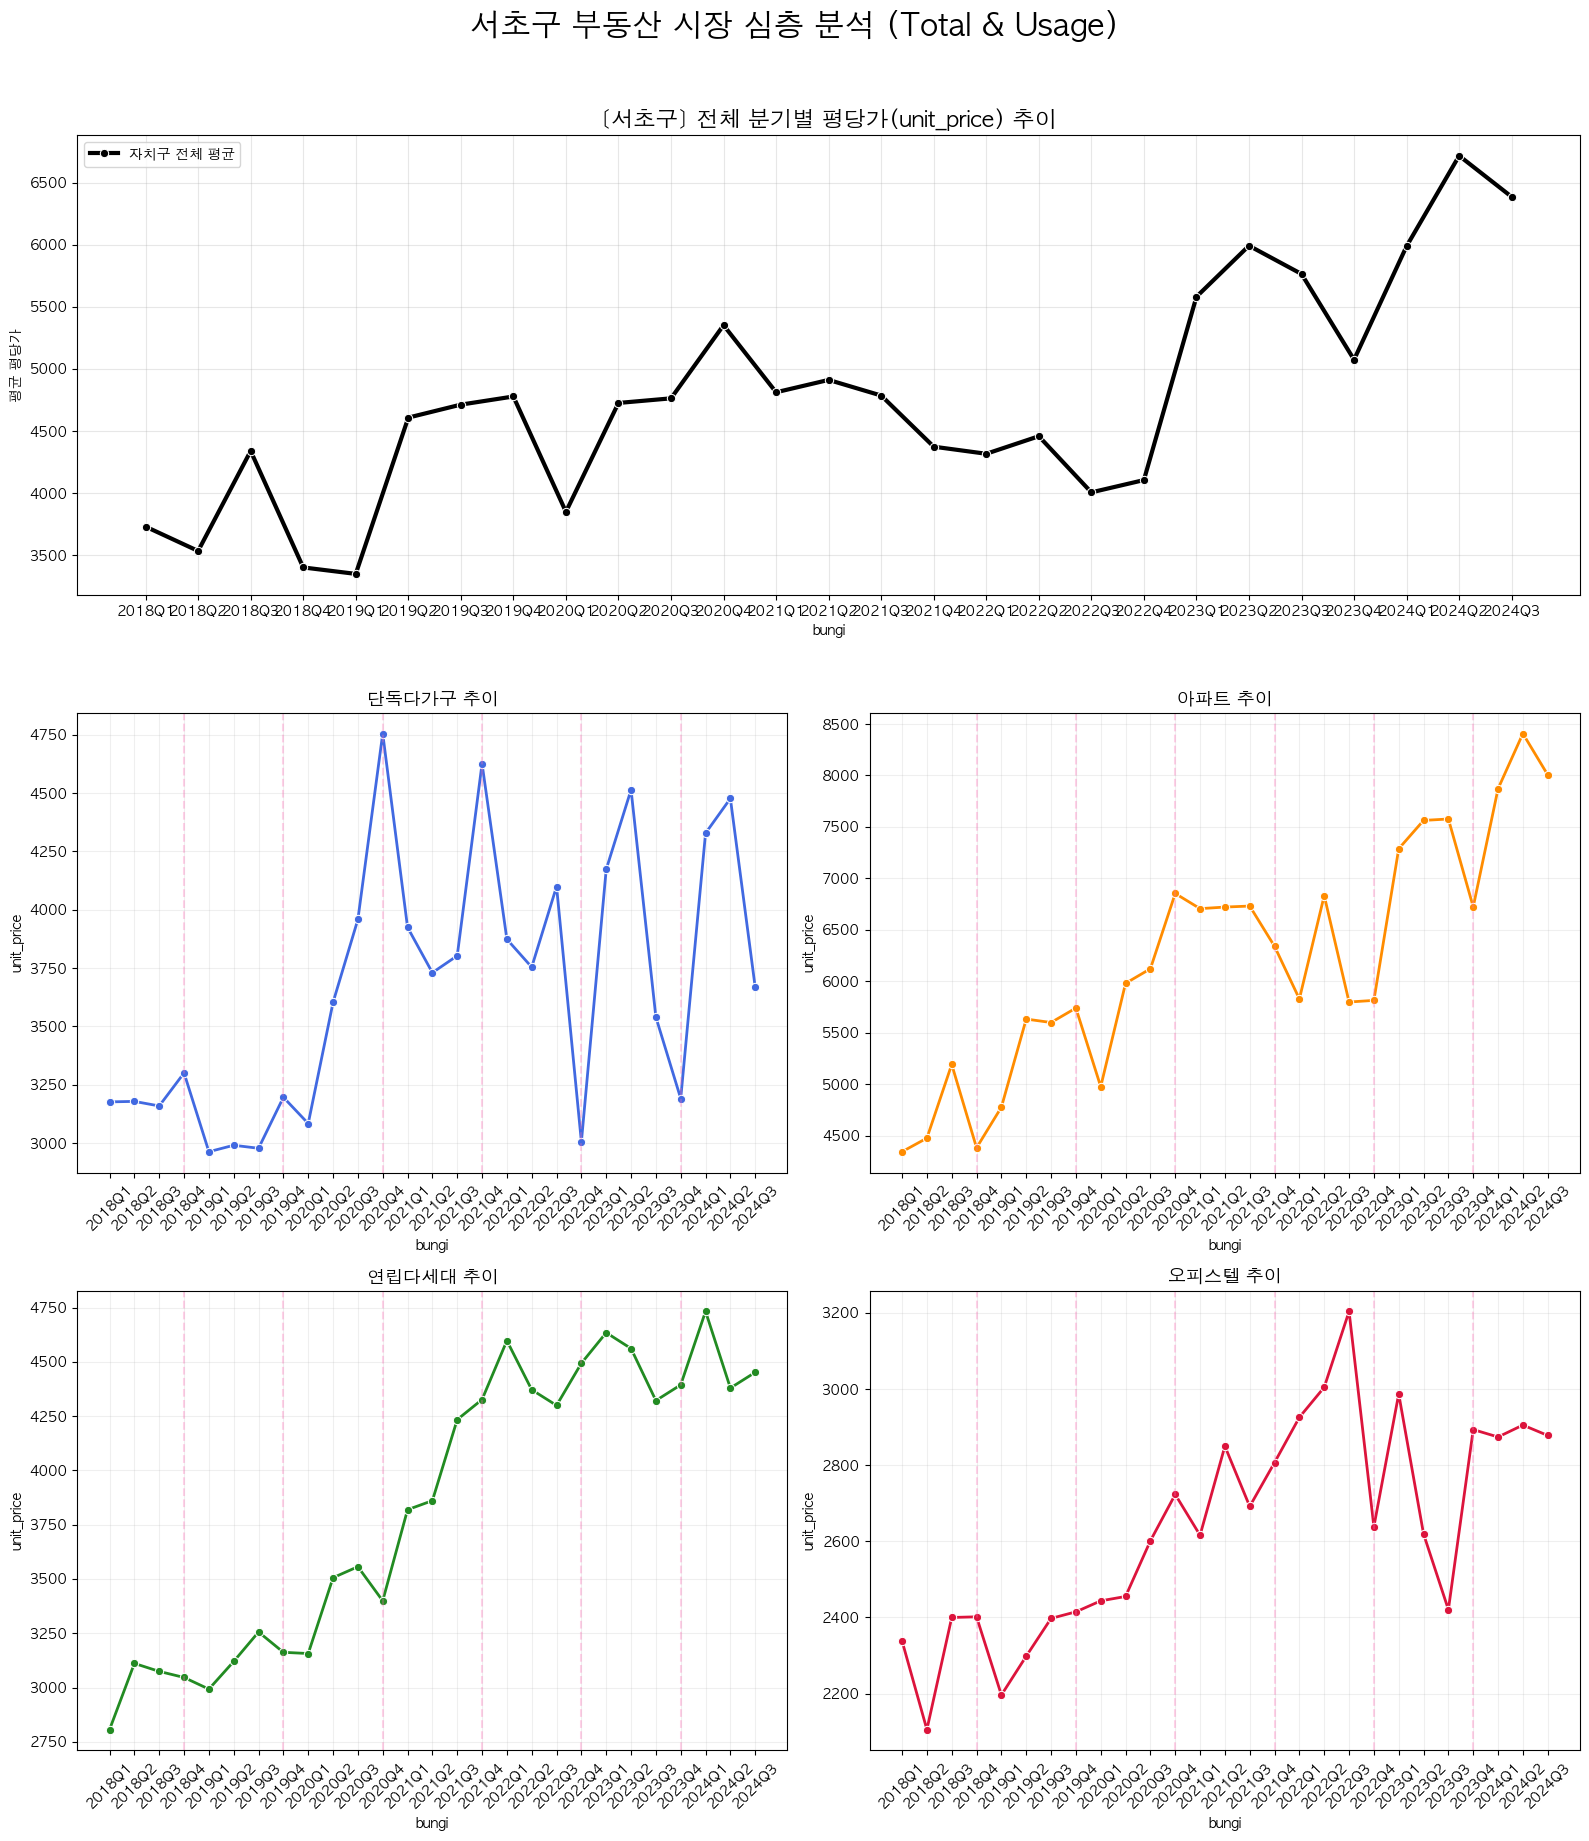

In [ ]:
# 실행 서초구
plot_gu_master_analysis(df, '서초구')

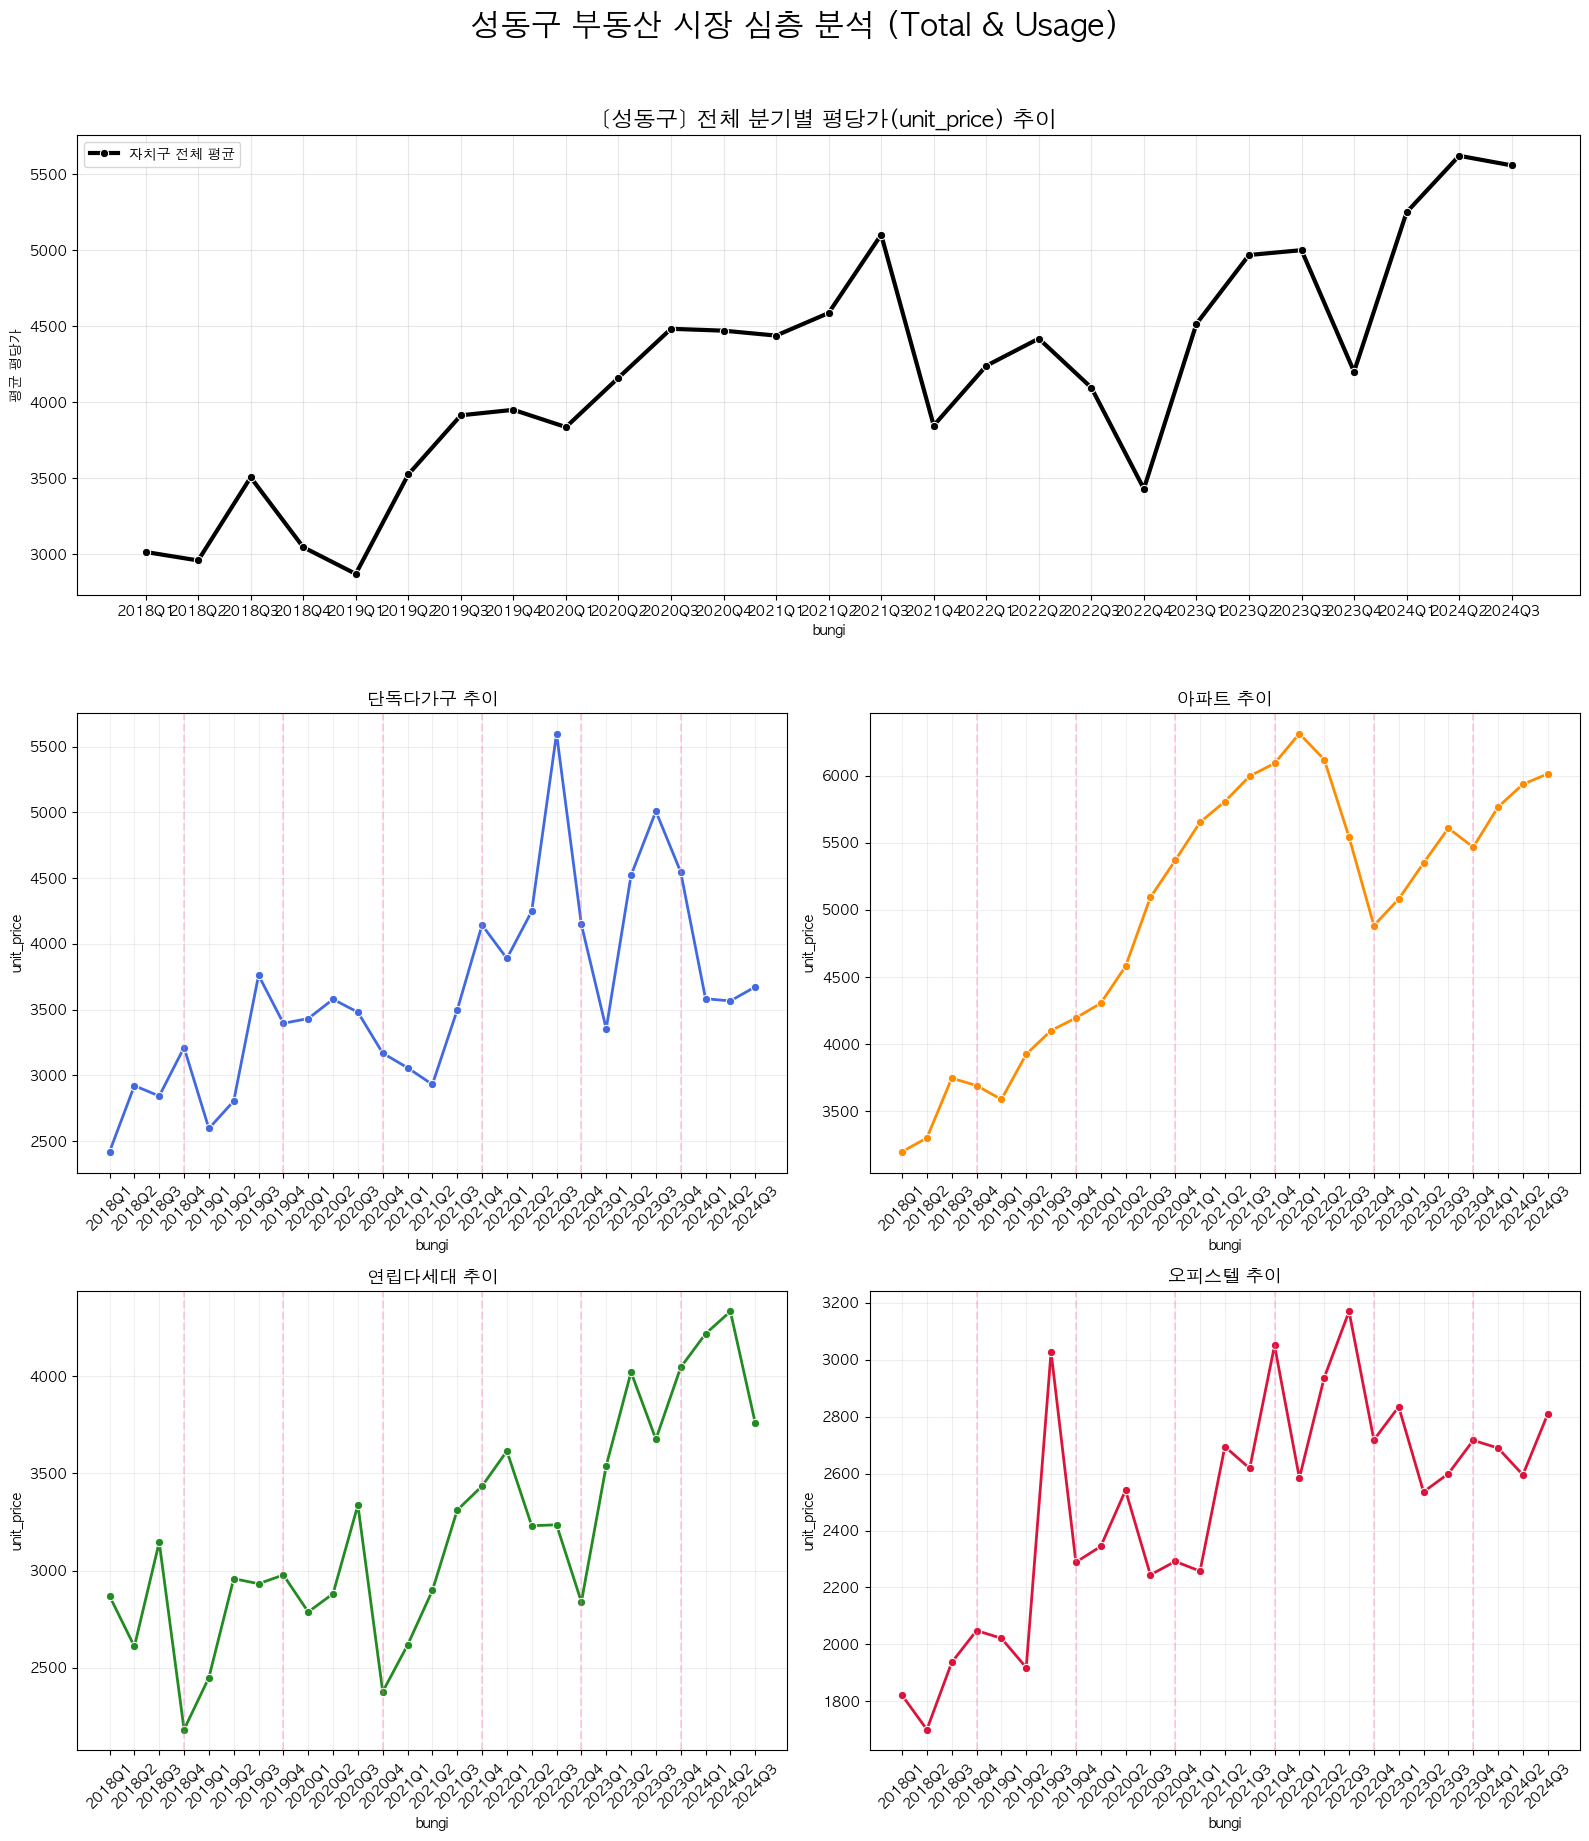

In [ ]:
# 실행 성동구
plot_gu_master_analysis(df, '성동구')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

def visualize_seoul_cagr_heatmap(bldg_type, start_year, start_quarter, duration_quarters):
    # 1. 기간 설정 (분기 단위 생성)
    # 시작 시점부터 duration_quarters 만큼의 (연도, 분기) 튜플 리스트 생성
    period_list = []
    current_y, current_q = start_year, start_quarter
   
    for _ in range(duration_quarters + 1): # 시작~종료 포함
        period_list.append((current_y, current_q))
       
        # 다음 분기 계산
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
           
    # Dataframe 필터링용 쿼리 (Period List에 있는 연도만 1차 필터링)
    target_years = sorted(list(set([y for y, q in period_list])))
   
    # 2. 데이터 추출 및 집계
    # 필요한 컬럼만 추출하여 메모리 절약
    mask = (
        (df2['CTRT_YEAR'].isin(target_years)) &
        (df2['BLDG_USG'] == bldg_type) &
        (df2['CGG_NM'].notnull())
    )
    temp_df = df2.loc[mask].copy()
   
    # (연도, 분기) 컬럼을 만들어 필터링
    temp_df['YR_Q'] = temp_df['CTRT_YEAR'].astype(str) + '-' + temp_df['Quarter'].astype(str) + 'Q'
   
    # 타겟 리스트를 문자열 포맷으로 변환 (예: "2018-1Q")
    target_period_strs = [f"{y}-{q}Q" for y, q in period_list]
   
    # 범위 내 데이터만 남기기
    final_df = temp_df[temp_df['YR_Q'].isin(target_period_strs)].copy()
   
    if final_df.empty:
        print("해당 기간/조건의 데이터가 없습니다.")
        return

    # 3. 자치구별, 시점별 평단가 평균 집계
    # pivot: Index=자치구, Columns=시점, Values=평단가
    pivot_price = final_df.pivot_table(index='CGG_NM', columns='YR_Q', values='AMT_PER_AREA', aggfunc='mean')
   
    # 컬럼 순서 정렬 (문자열 정렬 시 2018-10Q 같은게 없으므로 1Q~4Q 단순 정렬 가능, 연도가 앞에 있으므로)
    # 하지만 정확하게 period_list 순서대로 재정렬
    valid_cols = [c for c in target_period_strs if c in pivot_price.columns]
    pivot_price = pivot_price[valid_cols]
   
    # 4. 수익률 변환 (기준 시점 대비 누적 수익률 %)
    # 기준 시점(첫 컬럼)의 가격이 없는 자치구(NaN)는 제거
    idx_not_nan = pivot_price.iloc[:, 0].notna()
    pivot_price = pivot_price.loc[idx_not_nan]
   
    if pivot_price.empty:
        print("시작 시점의 데이터가 있는 자치구가 없습니다.")
        return

    base_prices = pivot_price.iloc[:, 0] # 시작 시점 가격
    growth_rate_df = pivot_price.div(base_prices, axis=0) # 비율 (1.xx)
    growth_rate_df = (growth_rate_df - 1) * 100 # 퍼센트 (xx.xx%)
   
    # 5. 정렬 (최종 수익률 높은 순)
    final_returns = growth_rate_df.iloc[:, -1]
    growth_rate_df = growth_rate_df.loc[final_returns.sort_values(ascending=False).index]
   
    # 6. Heatmap 시각화
    plt.figure(figsize=(15, 10))
   
    # 히트맵 그리기
    # annot=True: 숫자 표시, fmt='.1f': 소수점 1자리
    sns.heatmap(growth_rate_df, annot=True, fmt='.1f', cmap='RdBu_r', center=0, linewidths=0.5)
   
    plt.title(f"서울시 자치구별 {bldg_type} 누적 수익률(%) 히트맵 ({target_period_strs[0]} ~ {target_period_strs[-1]})", fontsize=16)
    plt.xlabel("기간 (분기)")
    plt.ylabel("자치구 (수익률 상위 순)")
    plt.xticks(rotation=45)
   
    plt.tight_layout()
    plt.show()
   
    # 상위 5개, 하위 5개 출력
    print(f"■ [{bldg_type}] 수익률 Top 3 (기간: {target_period_strs[0]} ~ {target_period_strs[-1]})")
    for i in range(min(3, len(growth_rate_df))):
        gu = growth_rate_df.index[i]
        ret = growth_rate_df.iloc[i, -1]
        print(f"{i+1}. {gu}: {ret:.2f}%")
       
    print(f"\n■ [{bldg_type}] 수익률 Bottom 3")
    for i in range(min(3, len(growth_rate_df))):
        gu = growth_rate_df.index[-(i+1)]
        ret = growth_rate_df.iloc[-(i+1), -1]
        print(f"{i+1}. {gu}: {ret:.2f}%")

# 실행 예시
visualize_seoul_cagr_heatmap("아파트", 2018, 1, 26)